In [12]:
import os
import re

def process_images(image_folder, output_file):
    image_names = os.listdir(image_folder)
    images_names = []
    with open(output_file, 'w') as file:
        for image_name in image_names:
            # Remove '_s_<number>' from the image name using regular expression
            processed_name = re.sub(r'_s_\d+', '', image_name)
            if processed_name not in images_names:
                images_names.append(processed_name)
                # Save the modified name to the text file
                file.write(processed_name + '\n')

if __name__ == "__main__":
    # Specify the input image folder and output text file
    input_folder = "/New_Volume/Rakesh/DATA_LMV2/BOE_TRAIN/train"
    output_text_file = "/New_Volume/Rakesh/DATA_LMV3/train.txt"

    # Call the function to process the images
    process_images(input_folder, output_text_file)

    print("Processing complete. Modified names saved to:", output_text_file)


Processing complete. Modified names saved to: /New_Volume/Rakesh/DATA_LMV3/train.txt


In [10]:
def find_common_image_names(file1, file2, train_images_path):
    # Read image names from text files into sets
    with open(file1, 'r') as f1, open(file2, 'r') as f2:
        image_names_set1 = set(line.strip() for line in f1)
        image_names_set2 = set(line.strip() for line in f2)
    combined_image_names = image_names_set1.union(image_names_set2)
    # Find common image names
    print(image_names_set1)
    print(image_names_set2)
    for i in combined_image_names:
        if i not in os.listdir(train_images_path):
            print(">>>>>>>>>>>>>>>>>>>>>")
            print(i)
    common_image_names = image_names_set1.intersection(image_names_set2)

    return common_image_names

if __name__ == "__main__":
    # Specify the paths to your text files
    file1_path = "/New_Volume/Rakesh/DATA_LMV3/train.txt"
    file2_path = "/New_Volume/Rakesh/DATA_LMV3/test.txt"
    train_images_path = '/New_Volume/Rakesh/DATA_LMV2/BOE_TRAIN/Images'

    # Find common image names
    common_names = find_common_image_names(file1_path, file2_path, train_images_path)

    # Print or process the common image names
    if common_names:
        print("Common Image Names:")
        for name in common_names:
            print(name)
    else:
        print("No common image names found.")


{'Bill_of_Exchange_459_0.png', 'Bill_of_Exchange_435_1.png', 'Bill_of_Exchange_429_0.png', 'Bill_of_Exchange_148_0.png', 'Bill_of_Exchange_265_2.png', 'Bill_of_Exchange_408_2.png', 'Bill_of_Exchange_453_0.png', 'Bill_of_Exchange(2013_04_15_10_05_59_4819)_454_0.png', 'Bill_of_Exchange_140_0.png', 'Bill_of_Exchange_185_0.png', 'Accepted_Bill_of_Exchange_304_0.png', 'Bill_of_Exchange_499_2.png', 'Bill_of_Exchange_194_1.png', 'Bill_of_Exchange_487_0.png', 'Bill_of_Exchange_299_0.png', 'Accepted_Bill_of_Exchange_308_2.png', 'Bill_of_Exchange_433_0.png', 'Bill_of_Exchange_165_1.png', 'Bill_of_Exchange_479_1.png', 'Bill_of_Exchange_96_1.png', 'Accepted_Bill_of_Exchange_396_6.png', 'Bill_of_Exchange_6_0.png', 'Bill_of_Exchange_499_0.png', 'Accepted_Bill_of_Exchange_358_0.png', 'Bill_of_Exchange_12_0.png', 'Bill_of_Exchange_237_1.png', 'Bill_of_Exchange_194_0.png', 'Bill_of_Exchange_236_0.png', 'Bill_of_Exchange_408_1.png', 'Bill_of_Exchange_127_0.png', 'Accepted_Bill_of_Exchange_343_0.png', 'B

In [13]:
def mirror_bbox(bndbox, img_width):
    x_min, y_min, x_max, y_max = bndbox
    new_xmin = img_width - x_max
    new_ymin = y_min
    new_xmax = img_width - x_min
    new_ymax = y_max
    return [new_xmin, new_ymin, new_xmax, new_ymax]


In [19]:
import cv2

def draw_bbox(image, bbox, color=(255, 0, 0), thickness=2):
    x, y, w, h = bbox
    cv2.rectangle(image, (int(x), int(y)), (int(x + w), int(y + h)), color, thickness)

def visualize_and_save_bboxes(image_path, original_bbox, mirrored_bbox, output_path):
    # Open the image using cv2
    img = cv2.imread(image_path)

    # Get the image width dynamically
    image_width = img.shape[1]

    # Draw the original bounding box on the image
    draw_bbox(img, original_bbox, color=(255, 0, 0), thickness=2)

    # Draw the mirrored bounding box on the image
    draw_bbox(img, mirrored_bbox, color=(0, 0, 255), thickness=2)

    # Save the image with bounding boxes
    cv2.imwrite(output_path, img)

if __name__ == "__main__":
    # Example usage:
    image_path = "/New_Volume/Rakesh/DATA_LMV2/BOE_TRAIN/Images/Accepted_Bill_of_Exchange_303_0.png"
    original_bbox = [12, 170, 25, 203]
    img = cv2.imread(image_path)
    output_path = "resulting_image_cv2.png"

    mirrored_bbox = mirror_bbox(original_bbox, img.shape[1])  # Use img.shape[1] as image_width

    # Visualize bounding boxes on the image and save the result using cv2
    visualize_and_save_bboxes(image_path, original_bbox, mirrored_bbox, output_path)


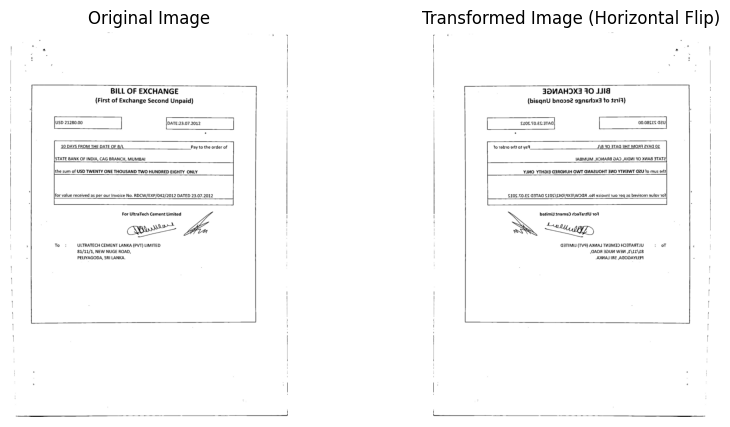

In [20]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load and process the image
image_path = "/New_Volume/Rakesh/DATA_LMV2/BOE_TRAIN/Images/Accepted_Bill_of_Exchange_303_0.png"
output_path = "transformed_image.png"

image = cv2.imread(image_path)

# Get the shape of the image
num_rows, num_cols = image.shape[:2]

# Define source and destination points for the affine transformation (horizontal flip)
src_points = np.float32([[0, 0], [num_cols-1, 0], [0, num_rows-1]])
dst_points = np.float32([[num_cols-1, 0], [0, 0], [num_cols-1, num_rows-1]])

# Calculate the transformation matrix
matrix = cv2.getAffineTransform(src_points, dst_points)

# Apply the affine transformation to the image
img_afftran = cv2.warpAffine(image, matrix, (num_cols, num_rows))

# Display the original and transformed images using matplotlib
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# Transformed image (horizontal flip)
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_afftran, cv2.COLOR_BGR2RGB))
plt.title("Transformed Image (Horizontal Flip)")
plt.axis('off')

# Save the transformed image
cv2.imwrite(output_path, img_afftran)
print("Transformed image saved to:", output_path)

plt.show()


In [ ]:
# String representation of a list
string_representation = "[bol, awb]"

# Remove the square brackets and split by comma
elements = string_representation[1:-1].split(', ')

# Convert elements to a Python list
my_list = [element.strip() for element in elements]

print(my_list)


In [ ]:
from data_preparation_with_debug import get_ocr_vision_api
a, b = get_ocr_vision_api('/New_Volume/Rakesh/DATA_LMV2/LMV2_BASE/BOL/Images/Bill_Of_Landing_106_page_9.png')

<h2> data augmentation

In [1]:
import cv2
import numpy as np

# Load image, create mask, and draw white circle on mask
image = cv2.imread('/home/ntlpt19/Downloads/Evaluation_Data/updated_code/src/main/extraction/resulting_image_cv2.png')
mask = np.zeros(image.shape, dtype=np.uint8)
mask = cv2.circle(mask, (260, 300), 225, (255,255,255), -1) 

# Mask input image with binary mask
result = cv2.bitwise_and(image, mask)
# Color background white
result[mask==0] = 255 # Optional

cv2.imshow('image', image)
cv2.imshow('mask', mask)
cv2.imshow('result', result)
cv2.waitKey()

<h2> circle mask

In [38]:
import cv2
import numpy as np

# Load image
image = cv2.imread('/home/ntlpt19/Downloads/Evaluation_Data/updated_code/src/main/extraction/resulting_image_cv2.png')

# Create a blank mask
mask = np.zeros(image.shape[:2], dtype=np.uint8)

# Define the center and radius of the circular mask for a small portion
center = (110, 200)
radius = 500

# Draw white circle on mask
mask = cv2.circle(mask, center, radius, (255, 255, 255), -1)

# Mask input image with binary mask
result = cv2.bitwise_and(image, image, mask=mask)

# Show the images
# cv2.imshow('image', image)
# cv2.imshow('mask', mask)
# cv2.imshow('result', result)
cv2.imwrite('pink_flower_masked1.png', result)

# cv2.waitKey(0)
# cv2.destroyAllWindows()


True

<h2> angle mask

In [45]:
import cv2
import numpy as np
import math

# Load image
image = cv2.imread('/home/ntlpt19/Downloads/Evaluation_Data/updated_code/src/main/extraction/resulting_image_cv2.png')

# Create a blank mask
mask = np.zeros(image.shape[:2], dtype=np.uint8)

# Specify the angle (in degrees) and the portion to be masked
angle = 30
mask_portion = 0.2  # Fraction of the image width to be masked

# Calculate the end points of the line segment
height, width = image.shape[:2]
angle_rad = math.radians(angle)
distance_from_corner = int(mask_portion * width)

start_point = (0, 0)
end_point = (distance_from_corner, height)

# Draw white line on mask
mask = cv2.line(mask, start_point, end_point, (255, 255, 255), 5)

# Toggle between masking and unmasking
masked_image = cv2.bitwise_and(image, image, mask=mask)
result = cv2.bitwise_xor(image, masked_image)

# Save the result
cv2.imwrite('toggled_mask_left_portion.png', result)



True

<h2> cone mask

In [48]:
import cv2
import numpy as np
import math

# Load image
image = cv2.imread('/home/ntlpt19/Downloads/Evaluation_Data/updated_code/src/main/extraction/resulting_image_cv2.png')

# Create a blank mask
mask = np.zeros(image.shape[:2], dtype=np.uint8)

# Specify the angle (in degrees) and the portion to be masked
angle = 30
mask_portion = 0.2  # Fraction of the image width to be masked

# Calculate the end points of the line segment
height, width = image.shape[:2]
angle_rad = math.radians(angle)
distance_from_corner = int(mask_portion * width)

start_point = (0, 0)
end_point = (distance_from_corner, height)

# Draw a polygon on the mask
pts = np.array([start_point, (0, height), end_point], dtype=np.int32)
pts = pts.reshape((-1, 1, 2))
cv2.fillPoly(mask, [pts], (255, 255, 255))

# Toggle between masking and unmasking
masked_image = cv2.bitwise_and(image, image, mask=mask)
result = cv2.bitwise_xor(image, masked_image)

# Save the result
cv2.imwrite('toggled_mask_left_portion.png', result)

# Show the images


True

<h2> box mask (black)

In [1]:
import cv2
import numpy as np

# Load image
image = cv2.imread('/home/ntlpt19/Downloads/Evaluation_Data/updated_code/src/main/extraction/resulting_image_cv2.png')

# Create a blank mask
mask = np.zeros(image.shape[:2], dtype=np.uint8)

# Define the center and radius of the circular mask for a small portion
center = (200, 200)
radius = 100

# Draw white circle on mask
mask = cv2.circle(mask, center, radius, (255, 255, 255), -1)

# Find contours of the mask
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Get the bounding box of the circular mask
x, y, w, h = cv2.boundingRect(contours[0])

# Create a mask for the bounding box
bbox_mask = np.ones_like(image, dtype=np.uint8) * 255
bbox_mask[y:y+h, x:x+w] = 0

# Set the region inside the bounding box to black
result = cv2.bitwise_and(image, bbox_mask)

# Save the result
cv2.imwrite('pink_flower_masked_with_bbox.png', result)


True

<h2> box mask (white)

In [ ]:
import cv2
import numpy as np

# Load image
image = cv2.imread('/home/ntlpt19/Downloads/Evaluation_Data/updated_code/src/main/extraction/resulting_image_cv2.png')

# Create a blank mask
mask = np.zeros(image.shape[:2], dtype=np.uint8)

# Define the center and radius of the circular mask for a small portion
# center = (500, 500)
center = (600, 600)
radius = 50

# Draw white circle on mask
mask = cv2.circle(mask, center, radius, (255, 255, 255), -1)

# Find contours of the mask
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(contours)
# Get the bounding box of the circular mask
x, y, w, h = cv2.boundingRect(contours[0])

# Create a mask for the bounding box
bbox_mask = np.zeros_like(image, dtype=np.uint8)
bbox_mask[y:y+h, x:x+w] = 255

# Set the region inside the bounding box to white
result = cv2.bitwise_or(image, bbox_mask)

# Save the result
cv2.imwrite('pink_flower_masked_with_bbox.png', result)


<h2> random masking

In [29]:
import cv2
import numpy as np
import random

def generate_random_circular_masks(image_shape, num_masks, min_distance, max_distance, min_radius, max_radius):
    mask = np.zeros(image_shape[:2], dtype=np.uint8)
    center_distances = set()

    for _ in range(num_masks):
        # Generate random center coordinates within the second half of the image
        center_x = random.randint(image_shape[1] // 2, image_shape[1] - 1)
        center_y = random.randint(image_shape[0] // 2, image_shape[0] - 1)

        # Check if the new center is at least min_distance away from existing centers
        if all(np.sqrt((center_x - x)**2 + (center_y - y)**2) >= min_distance for x, y in center_distances):
            center_distances.add((center_x, center_y))

    for center_x, center_y in center_distances:
        # Generate random radius
        radius = random.randint(min_radius, max_radius)

        # Draw white circle on mask
        mask = cv2.circle(mask, (center_x, center_y), radius, (255, 255, 255), -1)

    return mask

# Load image
image = cv2.imread('/home/ntlpt19/Downloads/Evaluation_Data/testing_aug/awb_output/Bill_Of_Landing_234_page_0_adjust.jpg')

# Define the number of circular masks
num_masks = 2

# Define the minimum and maximum distance between circular masks
min_distance = 100
max_distance = 300

# Define the minimum and maximum radius for the circular masks
min_radius = 20
max_radius = 70

# Generate random circular masks
mask = generate_random_circular_masks(image.shape, num_masks, min_distance, max_distance, min_radius, max_radius)

# Find contours of the mask
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Get the bounding box of the circular masks
x, y, w, h = cv2.boundingRect(np.vstack(contours))

# Create a mask for the bounding box
bbox_mask = np.zeros_like(image, dtype=np.uint8)
bbox_mask[y:y+h, x:x+w] = 255

# Set the region inside the bounding box to white
result = cv2.bitwise_or(image, bbox_mask)

# Save the result
cv2.imwrite('image_masked_with_random_circles.png', result)


True

<h2> draw lines

<h4> need to think about it

In [37]:
import cv2
import numpy as np
import random

# Path to the image
path = r'/home/ntlpt19/Downloads/Evaluation_Data/updated_code/src/main/extraction/resulting_image_cv2.png'

# Reading an image in grayscale mode 
image = cv2.imread(path, 0)

# Window name in which image is displayed 

# Function to draw random black lines across the image
def draw_random_lines_across_image(img, num_lines):
    for _ in range(num_lines):
        # Generate random y-coordinate for the line
        y_coordinate = random.randint(0, img.shape[0])

        # Draw a horizontal line across the image at the generated y-coordinate
        img = cv2.line(img, (0, y_coordinate), (img.shape[1], y_coordinate), 0, 2)

    return img

# Draw three random black lines across the image
image_with_lines = draw_random_lines_across_image(image.copy(), 3)

# Save the result
cv2.imwrite('random_lines_pink_flower_masked.png', image_with_lines)


True

<h2> folding

MissingSchema: Invalid URL '/home/ntlpt19/Downloads/Evaluation_Data/testing_aug/AWB/Bill_Of_Landing_234_page_0.png': No scheme supplied. Perhaps you meant http:///home/ntlpt19/Downloads/Evaluation_Data/testing_aug/AWB/Bill_Of_Landing_234_page_0.png?

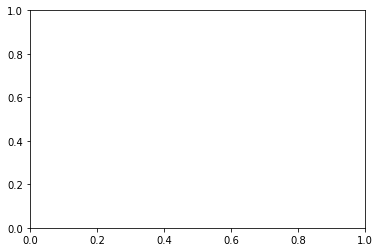

In [20]:

import numpy as np
import cv2
import matplotlib.pyplot as plt


def downloadImage(URL):
    """Downloads the image on the URL, and convers to cv2 BGR format"""
    from io import BytesIO
    from PIL import Image as PIL_Image
    import requests

    response = requests.get(URL)
    image = PIL_Image.open(BytesIO(response.content))
    return cv2.cvtColor(np.array(image), cv2.COLOR_BGR2RGB)


fig, ax = plt.subplots()

URL = "/home/ntlpt19/Downloads/Evaluation_Data/testing_aug/AWB/Bill_Of_Landing_234_page_0.png"
img = downloadImage(URL)[:, :, ::-1]  # BGR->RGB
plt.imshow(img)

selectedRectangle = None
# Capture mouse-drawing-rectangle event
def line_select_callback(eclick, erelease):
    x1, y1 = eclick.xdata, eclick.ydata
    x2, y2 = erelease.xdata, erelease.ydata

    selectedRectangle = plt.Rectangle(
        (min(x1, x2), min(y1, y2)),
        np.abs(x1 - x2),
        np.abs(y1 - y2),
        color="r",
        fill=False,
    )
    ax.add_patch(selectedRectangle)

    imgOnRectangle = img[
        int(min(y1, y2)) : int(max(y1, y2)), int(min(x1, x2)) : int(max(x1, x2))
    ]
    plt.figure()
    plt.imshow(imgOnRectangle)
    plt.show()


from matplotlib.widgets import RectangleSelector

rs = RectangleSelector(
    ax,
    line_select_callback,
    drawtype="box",
    useblit=False,
    button=[1],
    minspanx=5,
    minspany=5,
    spancoords="pixels",
    interactive=True,
)

plt.show()

<h2> corner

In [14]:
import cv2
import numpy as np
import math

def mask_corners_black(image, angle, mask_portion):
    # Create a blank mask
    mask = np.zeros(image.shape[:2], dtype=np.uint8)

    # Calculate the end points of the line segment for the bottom-left corner
    height, width = image.shape[:2]
    angle_rad = math.radians(angle)
    distance_from_corner = int(mask_portion * width)

    start_point_bottom_left = (0, height)
    end_point_bottom_left = (distance_from_corner, height - distance_from_corner)

    # Draw a filled polygon on the mask for the bottom-left corner
    bottom_left_pts = np.array([start_point_bottom_left, (0, height), end_point_bottom_left], dtype=np.int32)
    bottom_left_pts = bottom_left_pts.reshape((-1, 1, 2))
    cv2.fillPoly(mask, [bottom_left_pts], (255, 255, 255))

    # Calculate the end points of the line segment for the bottom-right corner
    start_point_bottom_right = (width, height)
    end_point_bottom_right = (width - distance_from_corner, height - distance_from_corner)

    # Draw a filled polygon on the mask for the bottom-right corner
    bottom_right_pts = np.array([start_point_bottom_right, (width, height), end_point_bottom_right], dtype=np.int32)
    bottom_right_pts = bottom_right_pts.reshape((-1, 1, 2))
    cv2.fillPoly(mask, [bottom_right_pts], (255, 255, 255))

    # Calculate the end points of the line segment for the top-left corner
    start_point_top_left = (0, 0)
    end_point_top_left = (distance_from_corner, distance_from_corner)

    # Draw a filled polygon on the mask for the top-left corner
    top_left_pts = np.array([start_point_top_left, (0, 0), end_point_top_left], dtype=np.int32)
    top_left_pts = top_left_pts.reshape((-1, 1, 2))
    cv2.fillPoly(mask, [top_left_pts], (255, 255, 255))

    # Calculate the end points of the line segment for the top-right corner
    start_point_top_right = (width, 0)
    end_point_top_right = (width - distance_from_corner, distance_from_corner)

    # Draw a filled polygon on the mask for the top-right corner
    top_right_pts = np.array([start_point_top_right, (width, 0), end_point_top_right], dtype=np.int32)
    top_right_pts = top_right_pts.reshape((-1, 1, 2))
    cv2.fillPoly(mask, [top_right_pts], (255, 255, 255))

    # Toggle between masking and unmasking
    masked_image = cv2.bitwise_and(image, image, mask=mask)
    result = cv2.bitwise_xor(image, masked_image)
    return result

# Example usage
img_path = '/home/ntlpt19/Downloads/Evaluation_Data/testing_aug/AWB_/Bill_Of_Landing_248_page_0.png'
image = cv2.imread(img_path)

# Check if the image was successfully loaded
if image is not None:
    result_image = mask_corners_black(image, angle=30, mask_portion=0.2)

    # Check if the result is not None before saving
    if result_image is not None:
        cv2.imwrite('masked_corners_all.png', result_image)
else:
    print(f"Error: Unable to load image from {img_path}")


In [21]:
import cv2
import numpy as np
import math

def angle_mask(img_path):
    image = cv2.imread(img_path)

    # Create a blank mask
    mask = np.zeros(image.shape[:2], dtype=np.uint8)

    # Specify the angle (in degrees) and the portion to be masked
    angle = 30
    mask_portion = 0.2  # Fraction of the image width to be masked

    # Calculate the end points of the line segment
    height, width = image.shape[:2]
    angle_rad = math.radians(angle)
    distance_from_corner = int(mask_portion * width)

    # Draw a polygon on the mask for the left portion
    left_pts = np.array([(0, 0), (0, height), (distance_from_corner, height)], dtype=np.int32)
    left_pts = left_pts.reshape((-1, 1, 2))
    cv2.fillPoly(mask, [left_pts], (255, 255, 255))

    # Draw a polygon on the mask for the right portion
    right_pts = np.array([(width, 0), (width, height), (width - distance_from_corner, height)], dtype=np.int32)
    right_pts = right_pts.reshape((-1, 1, 2))
    cv2.fillPoly(mask, [right_pts], (255, 255, 255))

    # Toggle between masking and unmasking
    masked_image = cv2.bitwise_and(image, image, mask=mask)
    result = cv2.bitwise_xor(image, masked_image)
    return result

# Example usage

img_path = '/home/ntlpt19/Downloads/Evaluation_Data/testing_aug/AWB_/Bill_Of_Landing_253_page_0.png'
result_image = angle_mask(img_path)

# Check if the result is not None before saving
if result_image is not None:
    cv2.imwrite('result_image_.png', result_image)


In [25]:
import cv2
import numpy as np
import math

def angle_mask(img_path):
    image = cv2.imread(img_path)

    # Create a blank mask
    mask = np.zeros(image.shape[:2], dtype=np.uint8)

    # Specify the angle (in degrees) and the portion to be masked
    angle = 10
    mask_portion = 0.2  # Fraction of the image width to be masked up to the middle

    # Calculate the end points of the line segment
    height, width = image.shape[:2]
    angle_rad = math.radians(angle)
    distance_from_corner = int(mask_portion * width)

    # Draw a polygon on the mask for the left portion
    left_pts = np.array([(0, height), (0, height // 2), (distance_from_corner, height // 2)], dtype=np.int32)
    left_pts = left_pts.reshape((-1, 1, 2))
    cv2.fillPoly(mask, [left_pts], (255, 255, 255))

    # Draw a polygon on the mask for the right portion
    right_pts = np.array([(width, height), (width, height // 2), (width - distance_from_corner, height // 2)], dtype=np.int32)
    right_pts = right_pts.reshape((-1, 1, 2))
    cv2.fillPoly(mask, [right_pts], (255, 255, 255))

    # Toggle between masking and unmasking
    masked_image = cv2.bitwise_and(image, image, mask=mask)
    result = cv2.bitwise_xor(image, masked_image)
    return result


img_path = '/home/ntlpt19/Downloads/Evaluation_Data/testing_aug/AWB_/Bill_Of_Landing_253_page_0.png'
result_image = angle_mask(img_path)

# Check if the result is not None before saving
if result_image is not None:
    cv2.imwrite('result_image_.png', result_image)


In [34]:
import cv2
import numpy as np
import math

def angle_mask(img_path):
    image = cv2.imread(img_path)

    # Create a blank mask
    mask = np.zeros(image.shape[:2], dtype=np.uint8)

    # Specify the angle (in degrees) and the portion to be masked
    angle = 80
    mask_portion = 0.2  # Fraction of the image width to be masked
    stop_distance_from_bottom = 500  # Distance from the bottom to stop the masking

    # Calculate the end points of the line segment
    height, width = image.shape[:2]
    angle_rad = math.radians(angle)
    distance_from_corner = int(mask_portion * width)

    # Calculate the stop point to prevent going to the top
    stop_point = (distance_from_corner, height - stop_distance_from_bottom)

    # Draw a polygon on the mask
    pts = np.array([(0, height), (0, stop_point[1]), stop_point], dtype=np.int32)
    pts = pts.reshape((-1, 1, 2))
    cv2.fillPoly(mask, [pts], (255, 255, 255))

    # Toggle between masking and unmasking
    masked_image = cv2.bitwise_and(image, image, mask=mask)
    result = cv2.bitwise_xor(image, masked_image)
    return result

img_path = '/home/ntlpt19/Downloads/Evaluation_Data/testing_aug/AWB_/Bill_Of_Landing_253_page_0.png'
result_image = angle_mask(img_path)

# Check if the result is not None before saving
if result_image is not None:
    cv2.imwrite('result_image_.png', result_image)

In [35]:
import cv2
import numpy as np
import math

def angle_mask(img_path):
    image = cv2.imread(img_path)

    # Create a blank mask
    mask = np.zeros(image.shape[:2], dtype=np.uint8)

    # Specify the angle (in degrees) and the portion to be masked
    angle = 80
    mask_portion = 0.2  # Fraction of the image width to be masked
    start_distance_from_bottom = 100  # Distance from the bottom to start the masking
    stop_distance_from_bottom = 500  # Distance from the bottom to stop the masking

    # Calculate the end points of the line segment
    height, width = image.shape[:2]
    angle_rad = math.radians(angle)
    start_point_x = int(mask_portion * width)
    start_point_y = height - start_distance_from_bottom
    stop_point_y = height - stop_distance_from_bottom

    # Draw a polygon on the mask
    pts = np.array([(start_point_x, height), (start_point_x, stop_point_y), (0, stop_point_y)], dtype=np.int32)
    pts = pts.reshape((-1, 1, 2))
    cv2.fillPoly(mask, [pts], (255, 255, 255))

    # Toggle between masking and unmasking
    masked_image = cv2.bitwise_and(image, image, mask=mask)
    result = cv2.bitwise_xor(image, masked_image)
    return result

img_path = '/home/ntlpt19/Downloads/Evaluation_Data/testing_aug/AWB_/Bill_Of_Landing_253_page_0.png'
result_image = angle_mask(img_path)

# Check if the result is not None before saving
if result_image is not None:
    cv2.imwrite('result_image_modified.png', result_image)


<h2> corner foldes

In [62]:
import cv2
import numpy as np
import math

def toggle_mask(img_path):
    image = cv2.imread(img_path)

    # Create a blank mask
    mask = np.zeros(image.shape[:2], dtype=np.uint8)

    # Specify the angle (in degrees) and the portion to be unmasked
    angle = 50
    mask_portion = 0.2  # Fraction of the image width to be unmasked
    start_distance_from_bottom = 250  # Distance from the bottom to start the unmasking

    # Calculate the end points of the line segment
    height, width = image.shape[:2]
    angle_rad = math.radians(angle)
    start_point_x = int(mask_portion * width)
    start_point_y = height - start_distance_from_bottom

    # Draw a rectangle on the mask for the left bottom corner
    cv2.rectangle(mask, (start_point_x, start_point_y), (0, height), (255, 255, 255), -1)

    # Calculate the end points of the diagonal
    diagonal_end_x = int(start_point_x - start_distance_from_bottom * math.tan(angle_rad))
    diagonal_end_y = height - start_distance_from_bottom

    # Draw a rectangle on the mask to unmask half of the square from the diagonal
    cv2.rectangle(mask, (start_point_x, start_point_y), (diagonal_end_x, diagonal_end_y), (0, 0, 0), -1)

    # Toggle between masking and unmasking
    unmasked_image = cv2.bitwise_and(image, image, mask=mask)
    masked_image = cv2.bitwise_xor(image, unmasked_image)

    # Save the result
    cv2.imwrite('unmasked_masked_toggle_diagonal.png', masked_image)

# Example usage
img_path = '/home/ntlpt19/Downloads/Evaluation_Data/testing_aug/AWB_/Bill_Of_Landing_253_page_0.png'
toggle_mask(img_path)


<h2> triangle mask

In [67]:
import cv2
import numpy as np

def toggle_mask_bottom_left_triangle(image_path, triangle_height):
    # Read the image
    image = cv2.imread(image_path)

    # Create a blank mask
    mask = np.zeros_like(image, dtype=np.uint8)

    # Define the vertices of the triangle
    height, width = image.shape[:2]
    vertices = np.array([[0, height], [0, height - triangle_height], [triangle_height, height]], dtype=np.int32)

    # Draw the triangle on the mask
    cv2.fillPoly(mask, [vertices], (255, 255, 255))

    # Toggle between masking and unmasking
    masked_image = cv2.bitwise_and(image, mask)
    unmasked_image = cv2.bitwise_xor(image, masked_image)

    return unmasked_image

# Example usage
image_path = '/home/ntlpt19/Downloads/Evaluation_Data/testing_aug/AWB_/Bill_Of_Landing_253_page_0.png'

triangle_height = 300  # Adjust the triangle height as needed
result_image = toggle_mask_bottom_left_triangle(image_path, triangle_height)

# Save the result
cv2.imwrite('toggled_bottom_left_triangle.png', result_image)


True

In [70]:
import cv2
import numpy as np

def toggle_mask_all_corners(image_path, mask_size):
    # Read the image
    image = cv2.imread(image_path)

    # Create a blank mask
    mask = np.zeros_like(image, dtype=np.uint8)

    # Define the vertices of the triangles in all four corners
    height, width = image.shape[:2]

    # Bottom-left triangle
    vertices_bl = np.array([[0, height], [0, height - mask_size], [mask_size, height]], dtype=np.int32)
    cv2.fillPoly(mask, [vertices_bl], (255, 255, 255))

    # Bottom-right triangle
    vertices_br = np.array([[width, height], [width, height - mask_size], [width - mask_size, height]], dtype=np.int32)
    cv2.fillPoly(mask, [vertices_br], (255, 255, 255))

    # Top-left triangle
    vertices_tl = np.array([[0, 0], [0, mask_size], [mask_size, 0]], dtype=np.int32)
    cv2.fillPoly(mask, [vertices_tl], (255, 255, 255))

    # Top-right triangle
    vertices_tr = np.array([[width, 0], [width, mask_size], [width - mask_size, 0]], dtype=np.int32)
    cv2.fillPoly(mask, [vertices_tr], (255, 255, 255))

    # Toggle between masking and unmasking
    masked_image = cv2.bitwise_and(image, mask)
    unmasked_image = cv2.bitwise_xor(image, masked_image)

    return unmasked_image

# Example usage
image_path = '/home/ntlpt19/Downloads/Evaluation_Data/testing_aug/AWB_/Bill_Of_Landing_253_page_0.png'

mask_size = 400  # Adjust the mask size as needed
result_image = toggle_mask_all_corners(image_path, mask_size)

# Save the result
cv2.imwrite('toggled_all_corners.png', result_image)


True

In [1]:
import os

dataset_path = "/New_Volume/Rakesh/DATA_CLASSIFICATION/Classification_final_training/LC"

# Remove 'LC' from the end of the path
dataset_path_without_lc = os.path.dirname(dataset_path)

print(dataset_path_without_lc)


/New_Volume/Rakesh/DATA_CLASSIFICATION/Classification_final_training


In [2]:
import os

dataset_path = "/New_Volume/Rakesh/DATA_CLASSIFICATION/Classification_final_training/LC"

# Get only the last component ('LC') from the path
lc_component = os.path.basename(dataset_path)

print(lc_component)


LC


In [1]:
label2idx = {"OTHERS": 0, "PI": 1, "PO": 2}

# Reverse the mapping to create idx2label
idx2label = {idx: label for label, idx in label2idx.items()}

print(idx2label)


{0: 'OTHERS', 1: 'PI', 2: 'PO'}


In [3]:
import os

folder_path = '/home/ntlpt19/Downloads/Classification_final_training/OCR_PATH'

# List all files in the directory
files = os.listdir(folder_path)

# Delete files ending with '_mask.json'
for file in files:
    if file.endswith('_mask.json') or file.endswith('_lines.json') or file.endswith('_noise.json'):
        file_path = os.path.join(folder_path, file)
        try:
            os.remove(file_path)
            print(f"File '{file_path}' deleted successfully.")
        except FileNotFoundError:
            print(f"File '{file_path}' not found.")
        except Exception as e:
            print(f"An error occurred: {e}")

File '/home/ntlpt19/Downloads/Classification_final_training/OCR_PATH/Purchase_Order_411_1_noise.json' deleted successfully.
File '/home/ntlpt19/Downloads/Classification_final_training/OCR_PATH/Purchase_Order_453_0_lines.json' deleted successfully.
File '/home/ntlpt19/Downloads/Classification_final_training/OCR_PATH/Purchase_Order_130_0_lines.json' deleted successfully.
File '/home/ntlpt19/Downloads/Classification_final_training/OCR_PATH/Purchase_Order_517_25_noise.json' deleted successfully.
File '/home/ntlpt19/Downloads/Classification_final_training/OCR_PATH/Purchase_Order_215_3_lines.json' deleted successfully.
File '/home/ntlpt19/Downloads/Classification_final_training/OCR_PATH/Proforma_Invoice_115_0_lines.json' deleted successfully.
File '/home/ntlpt19/Downloads/Classification_final_training/OCR_PATH/Purchase_Order_By_Opener_492_0_lines.json' deleted successfully.
File '/home/ntlpt19/Downloads/Classification_final_training/OCR_PATH/Purchase_Order_403_4_noise.json' deleted successfu

In [4]:
!pip install augraphy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 3.0 MB/s eta 0:00:00 MB/s eta 0:00:01
  Using cached scikit_image-0.21.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.9 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 11.0 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 MB 9.2 MB/s eta 0:00:000m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.3/313.3 kB 11.9 MB/s eta 0:00:00
  Using cached PyWavelets-1.4.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (6.9 MB)
  Using cached tifffile-2023.7.10-py3-none-any.whl (220 kB)
  Using cached lazy_loader-0.3-py3-none-any.whl (9.1 kB)
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.39.0
    Uninstalling llvmlite-0.39.0:
      Successfully uninstalled llvmlite-0.39.0
  Attempting uninstall: numba
    Found existing installation: numba 0.56.0
    Uninstalling numba-0.56.0:
      Successfully uninstalled num

In [7]:
from augraphy import *
import cv2
import numpy as np
pipeline = default_augraphy_pipeline()

image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

data = pipeline(image)

# augmented = data["output"]

In [11]:
from augraphy import *
import random

ink_phase = [Geometric(translation=(0, 0.2)),
             Squish(squish_direction=1,
                    squish_location='random',
                    squish_number_range=(5, 10),
                    squish_distance_range=(5, 7),
                    squish_line=0, squish_line_thickness_range=(1, 1))]

paper_phase = []

post_phase = [Folding(fold_x=None,
                      fold_deviation=(0, 0),
                      fold_count=random.randint(4,7),
                      fold_noise=0,
                      fold_angle_range=(0, 0),
                      gradient_width=(0.1, 0.2),
                      gradient_height=(0.01, 0.02),
                      backdrop_color=(0, 0, 0))]


pipeline = AugraphyPipeline(ink_phase=ink_phase, paper_phase=paper_phase, post_phase=post_phase, mask=mask, keypoints=keypoints, bounding_boxes=bounding_boxes)

image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

image_augmented = pipeline(image)

NameError: name 'mask' is not defined

In [104]:
from augraphy import *
import random

ink_phase = [Geometric(translation=(0, 0.2)),
             Squish(squish_direction=1,
                    squish_location='random',
                    squish_number_range=(5, 10),
                    squish_distance_range=(5, 7),
                    squish_line=0, squish_line_thickness_range=(1, 1))]

paper_phase = []

post_phase = [Folding(fold_x=None,
                      fold_deviation=(0, 0),
                      fold_count=random.randint(4,7),
                      fold_noise=0,
                      fold_angle_range=(0, 0),
                      gradient_width=(0.1, 0.2),
                      gradient_height=(0.01, 0.02),
                      backdrop_color=(0, 0, 0))]

pipeline = AugraphyPipeline(ink_phase=ink_phase, paper_phase=paper_phase, post_phase=post_phase, keypoints=None, bounding_boxes=None)

image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

image_augmented = pipeline(image)


# Save the augmented image
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, image_augmented)

True

In [ ]:
from augraphy import *
import random

ink_phase = [

    InkBleed(
        intensity_range=(0.5, 0.6),
        kernel_size=random.choice([(5, 5), (3, 3)]),
        severity=(0.2, 0.4),
        p=0.33,
    ),
    OneOf(
        [
            InkShifter(
                text_shift_scale_range=(18, 27),
                text_shift_factor_range=(1, 4),
                text_fade_range=(0, 2),
                blur_kernel_size=(5, 5),
                blur_sigma=0,
                noise_type="random",
            ),
            BleedThrough(
                intensity_range=(0.1, 0.3),
                color_range=(32, 224),
                ksize=(17, 17),
                sigmaX=1,
                alpha=random.uniform(0.1, 0.2),
                offsets=(10, 20),
            ),
        ],
        p=1.0,
    ),
]

paper_phase = [

    ColorPaper(
        hue_range=(0, 255),
        saturation_range=(10, 40),
        p=0.33,
    ),
            OneOf(
        [
            DelaunayTessellation(
                n_points_range=(500, 800),
                n_horizontal_points_range=(500, 800),
                n_vertical_points_range=(500, 800),
                noise_type="random",
                color_list="default",
                color_list_alternate="default",
            ),
            PatternGenerator(
                imgx=random.randint(256, 512),
                imgy=random.randint(256, 512),
                n_rotation_range=(10, 15),
                color="random",
                alpha_range=(0.25, 0.5),
            ),
            VoronoiTessellation(
                mult_range=(50, 80),
                seed=19829813472,
                num_cells_range=(500, 1000),
                noise_type="random",
                background_value=(200, 255),
            ),
        ],
        p=1.0,
    ),
    AugmentationSequence(
        [
            NoiseTexturize(
                sigma_range=(3, 10),
                turbulence_range=(2, 5),
            ),
            BrightnessTexturize(
                texturize_range=(0.9, 0.99),
                deviation=0.03,
            ),
        ],
    ),
]

post_phase = [
    OneOf(
        [
            DirtyDrum(
                line_width_range=(1, 6),
                line_concentration=random.uniform(0.05, 0.15),
                direction=random.randint(0, 2),
                noise_intensity=random.uniform(0.6, 0.95),
                noise_value=(64, 224),
                ksize=random.choice([(3, 3), (5, 5), (7, 7)]),
                sigmaX=0,
                p=0.2,
            ),
            DirtyRollers(
                line_width_range=(2, 32),
                scanline_type=0,
            ),
        ],
        p=1.0,
    ),
    SubtleNoise(
        subtle_range=random.randint(5, 10),
        p=0.33,
    ),
    Jpeg(
        quality_range=(25, 95),
        p=0.33,
    ),

    OneOf(
        [
            Markup(
                num_lines_range=(2, 7),
                markup_length_range=(0.5, 1),
                markup_thickness_range=(1, 2),
                markup_type=random.choice(["strikethrough", "crossed", "highlight", "underline"]),
                markup_color="random",
                single_word_mode=False,
                repetitions=1,
            ),
            Scribbles(
                scribbles_type="random",
                scribbles_location="random",
                scribbles_size_range=(250, 600),
                scribbles_count_range=(1, 6),
                scribbles_thickness_range=(1, 3),
                scribbles_brightness_change=[32, 64, 128],
                scribbles_text="random",
                scribbles_text_font="random",
                scribbles_text_rotate_range=(0, 360),
                scribbles_lines_stroke_count_range=(1, 6),
            ),
        ],
        p=1.0,
    ),
            OneOf(
        [
            GlitchEffect(
                glitch_direction="random",
                glitch_number_range=(8, 16),
                glitch_size_range=(5, 50),
                glitch_offset_range=(10, 50),
            ),
            ColorShift(
                color_shift_offset_x_range=(3, 5),
                color_shift_offset_y_range=(3, 5),
                color_shift_iterations=(2, 3),
                color_shift_brightness_range=(0.9, 1.1),
                color_shift_gaussian_kernel_range=(3, 3),
            ),
        ],
        p=1.0,
    ),
    BadPhotoCopy(
        mask=None,
        noise_type=-1,
        noise_side="random",
        noise_iteration=(1, 2),
        noise_size=(1, 3),
        noise_value=(128, 196),
        noise_sparsity=(0.3, 0.6),
        noise_concentration=(0.1, 0.6),
        blur_noise=random.choice([True, False]),
        blur_noise_kernel=random.choice([(3, 3), (5, 5), (7, 7)]),
        wave_pattern=random.choice([True, False]),
        edge_effect=random.choice([True, False]),
        p=0.33,
    ),

            Faxify(
        scale_range=(0.3, 0.6),
        monochrome=random.choice([0, 1]),
        monochrome_method="random",
        monochrome_arguments={},
        halftone=random.choice([0, 1]),
        invert=1,
        half_kernel_size=random.choice([(1, 1), (2, 2)]),
        angle=(0, 360),
        sigma=(1, 3),
        p=0.33,
    ),
]

# pipeline = AugraphyPipeline(ink_phase=ink_phase, paper_phase=paper_phase, post_phase=post_phase)
pipeline = AugraphyPipeline(ink_phase=ink_phase, paper_phase=paper_phase, post_phase=post_phase, keypoints=None, bounding_boxes=None)

# Load an image
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

# Apply augmentation pipeline
image_augmented = pipeline(image)

# Save the augmented image
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, image_augmented)

In [ ]:
import cv2
import numpy as np
from augraphy import *


# create a clean image with single line of text
image = np.full((500, 1500,3), 250, dtype="uint8")
cv2.putText(
    image,
    "Lorem ipsum dolor sit amet, consectetur adipiscing elit",
    (80, 250),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.5,
    0,
    3,
)

# cv2.imshow("Input image", image)

<h1> START

In [103]:
BadPhotoCopy_type_5 = BadPhotoCopy(noise_type=5,
                                   noise_side="all",
                                   noise_iteration=(1,1),
                                   noise_size=(1,3),
                                   noise_value=(32, 128),
                                   noise_sparsity=(0.3,0.3),
                                   noise_concentration=(0.5,0.5),
                                   blur_noise=0,
                                   wave_pattern=0,
                                   edge_effect=0)
img_BadPhotoCopy_type_5 = BadPhotoCopy_type_5(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_BadPhotoCopy_type_5)

True

In [102]:
BadPhotoCopy_type_4 = BadPhotoCopy(noise_type=4,
                                   noise_side="none",
                                   noise_iteration=(1,1),
                                   noise_size=(1,3),
                                   noise_value=(32, 255),
                                   noise_sparsity=(0.5,0.5),
                                   noise_concentration=(0.99,0.99),
                                   blur_noise=0,
                                   wave_pattern=0,
                                   edge_effect=0)
img_BadPhotoCopy_type_4 = BadPhotoCopy_type_4(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_BadPhotoCopy_type_4)

True

In [101]:
BadPhotoCopy_type_3 = BadPhotoCopy(noise_type=3,
                                   noise_side="none",
                                   noise_iteration=(1,1),
                                   noise_size=(1,3),
                                   noise_value=(128, 255),
                                   noise_sparsity=(0.2,0.3),
                                   noise_concentration=(0.5,0.5),
                                   blur_noise=1,
                                   blur_noise_kernel=(5, 5),
                                   wave_pattern=0,
                                   edge_effect=1)
img_BadPhotoCopy_type_3 = BadPhotoCopy_type_3(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_BadPhotoCopy_type_3)

True

In [100]:
BadPhotoCopy_type_2 = BadPhotoCopy(noise_type=2,
                                   noise_side="right",
                                   noise_iteration=(1,1),
                                   noise_size=(1,1),
                                   noise_sparsity=(0.4,0.5),
                                   noise_concentration=(0.2,0.2),
                                   blur_noise=1,
                                   blur_noise_kernel=(5, 5),
                                   wave_pattern=0,
                                   edge_effect=1)
img_BadPhotoCopy_type_2 = BadPhotoCopy_type_2(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_BadPhotoCopy_type_2)

True

In [99]:
BadPhotoCopy_type_1 = BadPhotoCopy(noise_type=1,
                                   noise_side="left",
                                   noise_iteration=(2,3),
                                   noise_size=(2,3),
                                   noise_sparsity=(0.15,0.15),
                                   noise_concentration=(0.3,0.3),
                                   blur_noise=-1,
                                   blur_noise_kernel=(5, 5),
                                   wave_pattern=0,
                                   edge_effect=0)
img_BadPhotoCopy_type_1 = BadPhotoCopy_type_1(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_BadPhotoCopy_type_1)

True

In [98]:
binder_binding_clips = BindingsAndFasteners(overlay_types="darken",
                                            foreground=None,
                                            effect_type="clips",
                                            width_range = "random",
                                            height_range = "random",
                                            ntimes= (2, 3),
                                            nscales=(1, 2),
                                            edge="random",
                                            edge_offset=(10,20),
                                            use_figshare_library=0,
                                            )

img_binding_clips = binder_binding_clips(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_binding_clips)

True

In [97]:
binder_rectangle = np.full((50,20),fill_value=250,dtype="uint8")
binder_rectangle[10:40,5:15] = 0


user_binder_clips = BindingsAndFasteners(overlay_types="darken",
                                         foreground=binder_rectangle,
                                         ntimes= (2, 3),
                                         nscales=(1, 2),
                                         edge="right",
                                         edge_offset=(10,20),
                                         use_figshare_library=0,
                                         )

img_user_binder = user_binder_clips(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_user_binder)

True

In [96]:
binder_binding_holes = BindingsAndFasteners(overlay_types="darken",
                                            foreground=None,
                                            effect_type="binding_holes",
                                            width_range = "random",
                                            height_range = "random",
                                            ntimes=(9, 10),
                                            nscales=(1, 2),
                                            edge="top",
                                            edge_offset=(40,50),
                                            use_figshare_library=0,
                                            )

img_binding_holes =binder_binding_holes(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_binding_holes)

True

In [95]:
binder_punch_holes = BindingsAndFasteners(overlay_types="darken",
                                          foreground=None,
                                          effect_type="punch_holes",
                                          width_range = (70,80),
                                          height_range = (70,80),
                                          ntimes=(3, 3),
                                          nscales=(1.5, 1.5),
                                          edge="left",
                                          edge_offset=(30,50),
                                          use_figshare_library=0,
                                          )

img_punch_holes =binder_punch_holes(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_punch_holes)

True

In [94]:
bleedthrough = BleedThrough(intensity_range=(0.1, 0.2),
                            color_range=(0, 224),
                            ksize=(17, 17),
                            sigmaX=0,
                            alpha=0.3,
                            offsets=(10, 20),
                        )

img_bleedthrough = bleedthrough(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_bleedthrough)

True

In [93]:
brightness_dimmer= Brightness(brightness_range=(0.2, 0.8),
                                min_brightness=1,
                                min_brightness_value=(120, 150),
                        )

img_brightness_dimmer= brightness_dimmer(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_brightness_dimmer)

True

In [91]:
brightness_brighten= Brightness(brightness_range=(1.5, 2),
                       min_brightness=0,
                    )

img_brightness_brighten= brightness_brighten(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_brightness_brighten)

True

In [89]:
brightness_texturize = BrightnessTexturize(texturize_range=(0.9, 0.99),
                                           deviation=0.1 )

img_brightness_texturize = brightness_texturize(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_brightness_texturize)

True

In [88]:
colorpaper= ColorPaper(hue_range=(0, 10), saturation_range=(10,30))

img_colorpaper = colorpaper(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_colorpaper)

True

In [86]:
colorshift = ColorShift(color_shift_offset_x_range = (3,5),
                        color_shift_offset_y_range = (3,5),
                        color_shift_iterations = (2,3),
                        color_shift_brightness_range = (0.9,1.1),
                        color_shift_gaussian_kernel_range = (3,3),
                        )

img_colorshift = colorshift(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_colorshift)

True

In [85]:
delaunay_pattern = DelaunayTessellation(
                                        n_points_range = (500, 800),
                                        n_horizontal_points_range=(50, 100),
                                        n_vertical_points_range=(50, 100),
                                        noise_type = "random")

img_final = delaunay_pattern(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_final)

True

Delaunay Tessellation pattern_width = 480, pattern_height= 480, no. of random points on geometric plane = 502, no. of horizontal edge points = 65, no. of vertical edge points = 68, perlin_noise = True, window_size = 120

Delaunay Tessellation pattern_width = 640, pattern_height= 640, no. of random points on geometric plane = 661, no. of horizontal edge points = 86, no. of vertical edge points = 73, perlin_noise = False, window_size = 160

In [4]:
depthsimulatedblur = DepthSimulatedBlur(blur_center = "random",
                                        blur_major_axes_length_range = (120, 200),
                                        blur_minor_axes_length_range = (120, 200),
                                        )


image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

# Apply augmentation pipeline

# Save the augmented image



img_depthsimulatedblur = depthsimulatedblur(image)
# cv2.imshow("depthsimulatedblur", img_depthsimulatedblur)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_depthsimulatedblur)

True

In [5]:
dirtydrum2 = DirtyDrum(line_width_range=(5, 10),
                      line_concentration=0.3,
                      direction=1,
                      noise_intensity=0.2,
                      noise_value=(0, 10),
                      ksize=(3, 3),
                      sigmaX=0,
                      )


image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_dirtydrum2 = dirtydrum2(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_dirtydrum2)

True

In [6]:
dirtydrum3 = DirtyDrum(line_width_range=(2, 5),
                      line_concentration=0.3,
                      direction=2,
                      noise_intensity=0.4,
                      noise_value=(0, 5),
                      ksize=(3, 3),
                      sigmaX=0,
                      )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_dirtydrum3 = dirtydrum3(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_dirtydrum3)

True

In [11]:
dirty_rollers = DirtyRollers(line_width_range=(12, 25),
                            scanline_type=0,
                            )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_dirty_rollers = dirty_rollers(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_dirty_rollers)

True

In [12]:
dirtyscreen = DirtyScreen(n_clusters = (50,100),
                                                      n_samples = (2,20),
                                                      std_range = (1,5),
                                                      value_range = (150,250),
                          )

image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_dirtyscreen = dirtyscreen(image)


output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_dirtyscreen)

True

In [14]:
dirther_ordered = Dithering(dither="ordered",
                            order=8,
                            )

image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_dither_ordered = dirther_ordered(image)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_dither_ordered)

TypeError: 'int' object is not subscriptable

In [16]:
dirther_floyd = Dithering(dither="floyd" )

image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")
img_dither_floyd = dirther_floyd(image)


output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_dither_floyd)

True

In [17]:
dotmatrix = DotMatrix(dot_matrix_shape="circle",
                      dot_matrix_dot_width_range=(5, 5),
                      dot_matrix_dot_height_range=(5, 5),
                      dot_matrix_min_width_range=(1, 1),
                      dot_matrix_max_width_range=(50, 50),
                      dot_matrix_min_height_range=(1, 1),
                      dot_matrix_max_height_range=(50, 50),
                      dot_matrix_min_area_range=(10, 10),
                      dot_matrix_max_area_range=(800, 800),
                      dot_matrix_median_kernel_value_range = (29,29),
                      dot_matrix_gaussian_kernel_value_range=(1, 1),
                      dot_matrix_rotate_value_range=(0, 0)
                      )

image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_dotmatrix = dotmatrix(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_dotmatrix)

True

In [18]:
doubleexposure = DoubleExposure(gaussian_kernel_range=(9,12),
                                offset_direction=1,
                                offset_range=(18,25),
                                )

image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_doubleexposure = doubleexposure(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_doubleexposure)

True

In [19]:
faxify = Faxify(scale_range = (1,2),
                monochrome = 1,
                monochrome_method = "cv2.threshold",
                monochrome_arguments = {"thresh":128, "maxval":128, "type":cv2.THRESH_BINARY},
                halftone = 1,
                invert = 1,
                half_kernel_size = (2,2),
                angle = (0, 360),
                sigma = (1,3))
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_faxify = faxify(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_faxify)

True

In [21]:
gamma = Gamma(gamma_range=(2.0, 3.0))
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_gamma= gamma(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_gamma)

True

In [23]:
hollow = Hollow(hollow_median_kernel_value_range = (101, 101),
                hollow_min_width_range=(1, 1),
                hollow_max_width_range=(200, 200),
                hollow_min_height_range=(1, 1),
                hollow_max_height_range=(200, 200),
                hollow_min_area_range=(10, 10),
                hollow_max_area_range=(5000, 5000),
                hollow_dilation_kernel_size_range = (3, 3),
                )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_hollow= hollow(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_hollow)

True

In [24]:
inkbleed = InkBleed(intensity_range=(0.4, 0.7),
                    kernel_size=(5, 5),
                    severity=(0.2, 0.4)
                    )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_inkbleed = inkbleed(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_inkbleed)

True

In [25]:
inkcolorswap= InkColorSwap(ink_swap_color = "random",
                           ink_swap_sequence_number_range = (1,10),
                           ink_swap_min_width_range=(3,3),
                           ink_swap_max_width_range=(100,100),
                           ink_swap_min_height_range=(3,3),
                           ink_swap_max_height_range=(100,100),
                           ink_swap_min_area_range=(10,10),
                           ink_swap_max_area_range=(400,400)
                           )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_inkcolorswap = inkcolorswap(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_inkcolorswap)

True

In [26]:
inkmottling= InkMottling(ink_mottling_alpha_range=(0.5, 0.5),
                         ink_mottling_noise_scale_range=(1,1),
                         ink_mottling_gaussian_kernel_range=(3,5),
                         )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_inkmottling = inkmottling(image)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_inkmottling)

True

In [28]:
lcdscreenpattern = LCDScreenPattern(pattern_type="Horizontal",
                                    pattern_value_range = (0,16),
                                    pattern_skip_distance_range = (3,5),
                                    pattern_overlay_method = "darken",
                                    )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_lcdscreenpattern = lcdscreenpattern(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_lcdscreenpattern)

True

<h2> time taking

In [31]:
lensflare = LensFlare(lens_flare_location = "random",
                      lens_flare_color = "random",
                      lens_flare_size = (0.5, 5),
                      )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_lensflare = lensflare(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_lensflare)

True

In [30]:
letterpress = Letterpress(n_samples=(200, 500),
                          n_clusters=(300, 800),
                          std_range=(1500, 5000),
                          value_range=(200, 255),
                          value_threshold_range=(128, 128),
                          blur=1
                          )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_letterpress = letterpress(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_letterpress)

True

In [32]:
lighting_gradient_gaussian = LightingGradient(light_position=None,
                                              direction=90,
                                              max_brightness=255,
                                              min_brightness=0,
                                              mode="gaussian",
                                              transparency=0.5
                                              )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_lighting_gradient_gaussian = lighting_gradient_gaussian(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_lighting_gradient_gaussian)

True

In [33]:
lighting_gradient_linear_static = LightingGradient(light_position=None,
                                              direction=45,
                                              max_brightness=255,
                                              min_brightness=0,
                                              mode="linear_static",
                                              linear_decay_rate = 0.5,
                                              transparency=0.5
                                              )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_lighting_gradient_linear_static= lighting_gradient_linear_static(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_lighting_gradient_linear_static)

True

In [36]:
lines_degradation = LinesDegradation(line_roi = (0.0, 0.0, 1.0, 1.0),
                                     line_gradient_range=(32, 255),
                                     line_gradient_direction= (1,1),
                                     line_split_probability=(0.2, 0.3),
                                     line_replacement_value=(250, 250),
                                     line_min_length=(15, 15),
                                     line_long_to_short_ratio = (3,3),
                                     line_replacement_probability = (0.5, 0.5),
                                     line_replacement_thickness = (1, 2)
                                     )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_lines_degradation = lines_degradation(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_lines_degradation)

True

In [37]:
lines_degradation = LinesDegradation(line_roi = (0.0, 0.0, 0.5, 1.0),
                                     line_gradient_range=(32, 255),
                                     line_gradient_direction= (2,2),
                                     line_split_probability=(0.2, 0.3),
                                     line_replacement_value=(0, 25),
                                     line_min_length=(15, 15),
                                     line_long_to_short_ratio = (3,3),
                                     line_replacement_probability = (1.0, 1.0),
                                     line_replacement_thickness = (2, 2)
                                     )
image = cv2.imread("/home/ntlpt19/Downloads/Classification_final_training/Bill_of_lading_1078_page_2.png")

img_lines_degradation = lines_degradation(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_lines_degradation)

True

In [38]:
low_ink_periodic_line_consistent =  LowInkPeriodicLines(count_range=(2, 5),
                                                        period_range=(30, 30),
                                                        use_consistent_lines=True,
                                                        noise_probability=0.1,
                                                        )

img_low_ink_periodic_line_consistent = low_ink_periodic_line_consistent(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_low_ink_periodic_line_consistent)

True

In [39]:
low_ink_periodic_line_non_consistent =  LowInkPeriodicLines(count_range=(2, 5),
                                                        period_range=(10, 30),
                                                        use_consistent_lines=False,
                                                        noise_probability=0.1,
                                                        )

img_low_ink_periodic_line_non_consistent = low_ink_periodic_line_non_consistent(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_low_ink_periodic_line_non_consistent)

True

In [40]:
lowlightnoise_obj = LowLightNoise(
    num_photons_range = (50, 100),
    alpha_range = (0.7, 0.9),
    beta_range = (10, 30),
    gamma_range = (1.0 , 1.8)
)

lowlightnoise_img = lowlightnoise_obj(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, lowlightnoise_img)

True

In [41]:
markup_strikethrough = Markup(num_lines_range=(5, 7),
                              markup_length_range=(0.5, 1),
                              markup_thickness_range=(1, 2),
                              markup_type="strikethrough",
                              markup_ink = "pencil",
                              markup_color=(0, 0, 255),
                              repetitions=4,
                              large_word_mode=1,
                              single_word_mode=False)

img_markup_strikethrough = markup_strikethrough(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_markup_strikethrough)

True

In [43]:
markup_highlight = Markup(num_lines_range=(1, 1),
                          markup_length_range=(0.5, 1),
                          markup_thickness_range=(5, 5),
                          markup_type="highlight",
                          markup_ink="highlighter",
                          markup_color=(0, 255, 0),
                          repetitions=1,
                          large_word_mode=1,
                          single_word_mode=False)

img_markup_highlight = markup_highlight(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_markup_highlight)

True

In [44]:
markup_underline = Markup(num_lines_range=(1, 1),
                          markup_length_range=(0.5, 1),
                          markup_thickness_range=(2, 2),
                          markup_type="underline",
                          markup_ink="marker",
                          markup_color=(255, 0, 0),
                          repetitions=1,
                          large_word_mode=1,
                          single_word_mode=False)

img_markup_underline = markup_underline(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_markup_underline)

True

In [45]:
moire = Moire(moire_density = (15,20),
              moire_blend_method = "normal",
              moire_blend_alpha = 0.1,
             )

img_moire = moire(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_moire)

True

In [47]:
noise_texturize = NoiseTexturize(sigma_range=(2, 3),
                                 turbulence_range=(2, 5),
                                 texture_width_range=(300, 500),
                                 texture_height_range=(50, 500),
                                 )

img_noise_texturize = noise_texturize(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_noise_texturize)


True

In [53]:
noisylines = NoisyLines(noisy_lines_direction = 0,
                        noisy_lines_location = "random",
                        noisy_lines_number_range = (3,5),
                        noisy_lines_color = (0,0,0),
                        noisy_lines_thickness_range = (2,2),
                        noisy_lines_random_noise_intensity_range = (0.01, 0.1),
                        noisy_lines_length_interval_range = (0,100),
                        noisy_lines_gaussian_kernel_value_range = (3,3),
                        noisy_lines_overlay_method = "ink_to_paper",
                        )


img_noisylines = noisylines(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_noisylines)

True

In [56]:
quasi_pattern = PatternGenerator(
    imgx = 512,
    imgy= 512,
    n_rotation_range = (10,15)
)

img_final = quasi_pattern(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_final)

True

In [57]:
reflected_light = NoiseTexturize(reflected_light_smoothness = 0.8,
                                 reflected_light_internal_radius_range=(0.0, 0.2),
                                 reflected_light_external_radius_range=(0.1, 0.8),
                                 reflected_light_minor_major_ratio_range = (0.9, 1.0),
                                 reflected_light_color = (255,255,255),
                                 reflected_light_internal_max_brightness_range=(0.9,1.0),
                                 reflected_light_external_max_brightness_range=(0.9,0.9),
                                 reflected_light_location = "random",
                                 reflected_light_ellipse_angle_range = (0, 360),
                                 reflected_light_gaussian_kernel_size_range = (5,310),
                                 )

img_reflected_light = reflected_light(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_reflected_light)

TypeError: __init__() got an unexpected keyword argument 'reflected_light_smoothness'

In [58]:
scribbles = Scribbles(scribbles_type="random",
                      scribbles_ink="random",
                      scribbles_location="random",
                      scribbles_size_range=(400, 600),
                      scribbles_count_range=(1, 6),
                      scribbles_thickness_range=(1, 3),
                      scribbles_brightness_change=[8, 16],
                      scribbles_skeletonize=0,
                      scribbles_skeletonize_iterations=(2, 3),
                      scribbles_color="random",
                      scribbles_text="random",
                      scribbles_text_font="random",
                      scribbles_text_rotate_range=(0, 360),
                      scribbles_lines_stroke_count_range=(1, 6),
                      )

img_scribbles = scribbles(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_scribbles)

True

In [59]:
shadowcast = ShadowCast(shadow_side = "bottom",
                        shadow_vertices_range = (2, 3),
                        shadow_width_range=(0.5, 0.8),
                        shadow_height_range=(0.5, 0.8),
                        shadow_color = (0, 0, 0),
                        shadow_opacity_range=(0.5,0.6),
                        shadow_iterations_range = (1,2),
                        shadow_blur_kernel_range = (101, 301),
                        )

img_shadowcast = shadowcast(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_shadowcast)

True

In [60]:
subtle_noise = SubtleNoise(subtle_range=25)

img_subtle_noise = subtle_noise(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_subtle_noise)

True

In [61]:
voronoi_pattern = VoronoiTessellation(
                         mult_range = (50,80),
                         seed = 19829813472 ,
                         num_cells_range = (500,800),
                         noise_type = "random",
                         background_value = (200, 256)
                        )

img_voronoi = voronoi_pattern(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_voronoi)

True

Voronoi Tessellation: width = 140. height = 140, amplification_factor_range = 64 , seed = 19829813472, number of random points = 1975, perlin=True, background_value = (200, 256), window_size=70

Voronoi Tessellation: width = 200. height = 200, amplification_factor_range = 63 , seed = 19829813472, number of random points = 733, perlin=False, background_value = (200, 256), window_size=200

In [62]:
watermark= WaterMark(watermark_word = "random",
                    watermark_font_size = (10,15),
                    watermark_font_thickness = (20,25),
                    watermark_font_type = cv2.FONT_HERSHEY_SIMPLEX,
                    watermark_rotation = (0,360), 
                    watermark_location = "center", 
                    watermark_color = (0,0,255), 
                    watermark_method = "darken")

img_watermark = watermark(image) 

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_watermark)

True

In [63]:
book_binder_up = BookBinding(shadow_radius_range=(100, 100),
                             curve_range_right=(300, 300),
                             curve_range_left=(300, 300),
                             curve_ratio_right = (0.3, 0.3),
                             curve_ratio_left = (0.3, 0.3),
                             mirror_range=(1.0, 1.0),
                             binding_align = 0,
                             binding_pages = (10,10),
                             curling_direction=0,
                             backdrop_color=(255, 255, 255),
                             enable_shadow=1,
                             use_cache_images = 0,
                             )

img_book_binding_up = book_binder_up(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_book_binding_up)

True

In [64]:
book_binder_down = BookBinding(shadow_radius_range=(100, 100),
                              curve_range_right=(50, 50),
                              curve_range_left=(300, 300),
                              curve_ratio_right = (0.05, 0.05),
                              curve_ratio_left = (0.3, 0.3),
                              mirror_range=(0.50, 0.50),
                              binding_align = 1,
                              binding_pages = (10,10),
                              curling_direction=1,
                              backdrop_color=(255, 255, 255),
                              enable_shadow=0,
                              use_cache_images = 0,
                              )


img_book_binding_down = book_binder_down(image)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_book_binding_down)

True

In [65]:
folding = Folding(fold_count=10,
                  fold_noise=0.0,
                  fold_angle_range = (-360,360),
                  gradient_width=(0.1, 0.2),
                  gradient_height=(0.01, 0.1),
                  backdrop_color = (0,0,0),
                  )

img_folded= folding(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_folded)

True

In [66]:
geometric = Geometric(scale=(0.5, 1.5),
                      translation=(50, -50),
                      fliplr=1,
                      flipud=1,
                      crop=(),
                      rotate_range=(3, 5)
                      )

img_geometric_transform = geometric(image)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_geometric_transform)

True

In [70]:
geometric = Geometric(rotate_range=(-10,10))

img_geometric_transform = geometric(image)#, mask, keypoints, bounding_boxes)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_geometric_transform)

True

In [71]:
geometric = Geometric(crop=(0.2, 0.2, 0.8, 0.8))

img_geometric_transform = geometric(image)#, mask, keypoints, bounding_boxes)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_geometric_transform)

True

In [72]:
geometric = Geometric(fliplr=1, flipud=1)

img_geometric_transform= geometric(image)#, mask, keypoints, bounding_boxes)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_geometric_transform)

True

In [73]:
glitcheffect= GlitchEffect(glitch_direction = "horizontal",
                           glitch_number_range = (8, 16),
                           glitch_size_range = (5, 50),
                           glitch_offset_range = (5, 10)
                           )

img_glitcheffect = glitcheffect(image)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_glitcheffect)

True

In [74]:
glitcheffect= GlitchEffect()

img_glitcheffect = glitcheffect(image=image)#, mask=mask, keypoints=keypoints, bounding_boxes=bounding_boxes)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_glitcheffect)

True

In [75]:
inkshifter_obj = InkShifter(
    text_shift_scale_range=(18, 27),
    text_shift_factor_range=(1, 4),
    text_fade_range=(0, 2),
    noise_type = "random",
)
inkshifter_img = inkshifter_obj(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, inkshifter_img)

True

In [76]:
page_border = PageBorder(page_border_width_height = (30, -40),
                         page_border_color=(0, 0, 0),
                         page_border_background_color=(255, 255, 255),
                         page_border_use_cache_images = 0,
                         page_border_trim_sides = (0, 0, 0, 0),
                         page_numbers = 10,
                         page_rotate_angle_in_order = 0,
                         page_rotation_angle_range = (1, 5),
                         curve_frequency=(0, 1),
                         curve_height=(1, 2),
                         curve_length_one_side=(30, 60),
                         same_page_border=0,
                         )
img_page_border = page_border(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_page_border)

True

In [77]:
page_border = PageBorder()

img_page_border = page_border(image=image)#, mask=mask, keypoints=keypoints, bounding_boxes=bounding_boxes)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_page_border)

True

In [80]:
rescale = Rescale(target_dpi=300)

pipeline1 = AugraphyPipeline(pre_phase=[rescale], ink_phase=[InkBleed()], paper_phase=[ColorPaper()], post_phase=[BleedThrough()], fixed_dpi=1)
pipeline2 = AugraphyPipeline(pre_phase=[rescale], ink_phase=[InkBleed()], paper_phase=[ColorPaper()], post_phase=[BleedThrough()], fixed_dpi=0)

img_rescale1 = pipeline1(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_rescale1)

# img_rescale1 = pipeline2(image)

# output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
# cv2.imwrite(output_path, img_rescale1)

True

In [79]:
rescale = Rescale(target_dpi=300)

img_rescale = rescale(image=image)#, mask=mask, keypoints=keypoints, bounding_boxes=bounding_boxes)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_rescale)

True

In [81]:
sectionshift = SectionShift(section_shift_number_range = (5,5),
                            section_shift_locations = "random",
                            section_shift_x_range = (20,20),
                            section_shift_y_range = (20,20),
                            section_shift_fill_value = (255,255,255)
                            )

img_sectionshift = sectionshift(image)
output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_sectionshift)

True

In [82]:
sectionshift = SectionShift()

img_sectionshift = sectionshift(image=image)#, mask=mask, keypoints=keypoints, bounding_boxes=bounding_boxes)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_sectionshift)

True

In [83]:
squish = Squish(squish_direction = 1,
                squish_location = "random",
                squish_number_range = (5,10),
                squish_distance_range = (5,7),
                squish_line = "random",
                squish_line_thickness_range = (1,1)
                )

img_squish = squish(image)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_squish)

True

In [84]:
squish = Squish()

img_squish = squish(image=image)#, mask=mask, keypoints=keypoints, bounding_boxes=bounding_boxes)

output_path = "aug_result_image.jpg"  # Specify your desired output path and file name
cv2.imwrite(output_path, img_squish)

True

In [46]:

def are_on_same_line(bbox1, bbox2, min_distance=0, tolerance=10):
    # Check if the vertical distance between the bottom of bbox1 and the top of bbox2 is within the tolerance
    # and if the overall distance is at least min_distance
    return (
        abs(bbox2[1] - bbox1[1]) <= tolerance
        and abs(bbox2[0] - bbox1[2]) >= min_distance
    )

def check_same_line_bbox(bbox_data, line_tolerance=10):
    all_bboxes_ = []
    line_wise_index = {}
    initial_bbox = []
    # Create sublists of OCR data in the same line with horizontal tolerance
    idx = 0
    for master_bbox in bbox_data:
        check_flag = False
        bbox = master_bbox
        if bbox not in all_bboxes_:
            all_bboxes_.append(bbox)
            line_wise_index[idx] = [bbox]
            check_flag = True

        if check_flag:
            prev_bbox = line_wise_index[idx][0]
            print("prev_bbox >>>>>>>>>>>", prev_bbox)
            for single_bbox in bbox_data:
                print('single_bbox>>>>>>>>>>>>>', single_bbox)
                if are_on_same_line(prev_bbox, single_bbox, tolerance=line_tolerance):
                    if single_bbox not in all_bboxes_:
                        line_wise_index[idx].append(single_bbox)
                        all_bboxes_.append(single_bbox)
            line_wise_index[idx].sort(key=lambda x: x[0])
            initial_bbox.append(line_wise_index[idx][0])
            idx += 1
    print(initial_bbox)
    initial_bbox.sort(key=lambda x: x[1])
    print(initial_bbox)
    updated_line_wise_data = []
    for bx in initial_bbox:
        for idx, values in line_wise_index.items():
            if bx in values:
                updated_line_wise_data.append(values)
    
    
    return updated_line_wise_data



In [47]:
abc = [['pefrey', [69, 87, 113, 96]], ['460', [70, 76, 83, 83]], ['5', [84, 76, 88, 83]],\
    ['v.f', [91, 76, 104, 83]], ['road', [106, 76, 130, 83]], ['mumbai', [70, 101, 105, 110]],\
        ['400', [105, 101, 119, 108]], ['mansion', [114, 87, 152, 94]], ['004', [120, 101, 133, 108]]]
abc = [['k.d.', [441, 678, 495, 698]], ['exports', [500, 675, 600, 696]]]
bboxes = []
for i in abc:
    bboxes.append(i[-1])
print(bboxes)
# bboxes = [[105, 101, 119, 108], [120, 101, 133, 108], [70, 101, 105, 110]]
print(check_same_line_bbox(bboxes))
# final_text = ''
# for index, values in check_same_line_bbox(bboxes).items():
#     for val in values:
#         for j in abc:
#             if j[-1] == val:
#                 final_text += j[0]+" "
# print(final_text)

[[441, 678, 495, 698], [500, 675, 600, 696]]
prev_bbox >>>>>>>>>>> [441, 678, 495, 698]
single_bbox>>>>>>>>>>>>> [441, 678, 495, 698]
single_bbox>>>>>>>>>>>>> [500, 675, 600, 696]
[[441, 678, 495, 698]]
[[441, 678, 495, 698]]
[[[441, 678, 495, 698], [500, 675, 600, 696]]]


In [33]:
def group_tokens_by_line(ocr_results, threshold=5):
   ocr_results.sort(key=lambda x: x[0])  # Sort by Y-coordinate
   lines = [[]]
   current_line = [[]]
   for token in ocr_results:
      y_coordinate = token[1]

      if current_line[-1] != [] and abs(y_coordinate - current_line[-1][1]) <= threshold:
         current_line.append(token)
      else:
         current_line = [token]
         lines.append(current_line)

   return lines

In [35]:
word_bbox = [['pefrey', [69, 87, 113, 96]], ['460', [70, 76, 83, 83]], ['5', [84, 76, 88, 83]], ['v.f', [91, 76, 104, 83]], ['road', [106, 76, 130, 83]], ['mumbai', [70, 101, 105, 110]], ['400', [105, 101, 119, 108]], ['mansion', [114, 87, 152, 94]], ['004', [120, 101, 133, 108]]]
# word_bbox = [['k.d.', [441, 678, 495, 698]], ['exports', [500, 675, 600, 696]]]
all_bboxes = []
for i in word_bbox:
    all_bboxes.append(i[-1])
print(all_bboxes)
final_word_bbox = []
# for index, values in check_same_line_bbox(bboxes).items():
ordered_bbox = group_tokens_by_line(all_bboxes)
for values in ordered_bbox:
    for val in values:
        for j in word_bbox:
            if j[-1] == val:
                final_word_bbox.extend([j])
print(final_word_bbox)

[[69, 87, 113, 96], [70, 76, 83, 83], [84, 76, 88, 83], [91, 76, 104, 83], [106, 76, 130, 83], [70, 101, 105, 110], [105, 101, 119, 108], [114, 87, 152, 94], [120, 101, 133, 108]]
[['pefrey', [69, 87, 113, 96]], ['460', [70, 76, 83, 83]], ['mumbai', [70, 101, 105, 110]], ['5', [84, 76, 88, 83]], ['v.f', [91, 76, 104, 83]], ['400', [105, 101, 119, 108]], ['road', [106, 76, 130, 83]], ['mansion', [114, 87, 152, 94]], ['004', [120, 101, 133, 108]]]


In [ ]:
#pefrey 460 5 v.f road mumbai 400 mansion 004                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [ ]:
'''[[69, 87, 113, 96], [70, 76, 83, 83], [84, 76, 88, 83], [91, 76, 104, 83], [106, 76, 130, 83], [70, 101, 105, 110], [105, 101, 119, 108], [114, 87, 152, 94], [120, 101, 133, 108]]

[[], [[70, 76, 83, 83], [84, 76, 88, 83], [91, 76, 104, 83], [106, 76, 130, 83]], [[69, 87, 113, 96], [114, 87, 152, 94]], [[70, 101, 105, 110], [105, 101, 119, 108], [120, 101, 133, 108]]]
460 5 v.f road pefrey mansion mumbai 400 004'''


In [ ]:
[[[70, 76, 83, 83], [84, 76, 88, 83], [91, 76, 104, 83], [106, 76, 130, 83]], [[69, 87, 113, 96], [114, 87, 152, 94]], [[70, 101, 105, 110], [105, 101, 119, 108], [120, 101, 133, 108]]]

In [20]:
abc = [['pefrey', [69, 87, 113, 96]], ['460', [70, 76, 83, 83]], ['5', [84, 76, 88, 83]], ['v.f', [91, 76, 104, 83]], ['road', [106, 76, 130, 83]], ['mumbai', [70, 101, 105, 110]], ['400', [105, 101, 119, 108]], ['mansion', [114, 87, 152, 94]], ['004', [120, 101, 133, 108]]]
bboxes = []
for i in abc:
    bboxes.append(i[-1])
print(bboxes)
print(check_same_line_bbox(bboxes))
# final_text = ''
# for index, values in check_same_line_bbox(bboxes).items():
#     for val in values:
#         for j in abc:
#             if j[-1] == val:
#                 final_text += j[0]+" "
# print(final_text)

[[69, 87, 113, 96], [70, 76, 83, 83], [84, 76, 88, 83], [91, 76, 104, 83], [106, 76, 130, 83], [70, 101, 105, 110], [105, 101, 119, 108], [114, 87, 152, 94], [120, 101, 133, 108]]
>>>>>>>>>>>>>>>>>>>>> [105, 101, 119, 108]
>>>>>>>>>>>>>>>>>>>>> [114, 87, 152, 94]
>>>>>>>>>>>>>>>>>>>>> [120, 101, 133, 108]
>>>>>>>>>>>>>>>>>>>>>>>
[120, 101, 133, 108]
{0: [[69, 87, 113, 96]], 1: [[70, 76, 83, 83]], 2: [[84, 76, 88, 83]], 3: [[91, 76, 104, 83]], 4: [[106, 76, 130, 83]], 5: [[70, 101, 105, 110], [120, 101, 133, 108]], 6: [[105, 101, 119, 108]], 7: [[114, 87, 152, 94]]}


In [5]:
import os
import shutil
total_imgs_folder = '/home/ntlpt19/Downloads/Final_Delivery_Training_itter_2/Proforma_invoice_418/Images'
eval_imgs = '/home/ntlpt19/Downloads/Evaluation_Data/FinalEvaluationEvalData/PI/Images'
eavl_data = os.listdir(eval_imgs)
total_data = os.listdir(total_imgs_folder)
cou = 0

for i in total_data:
    if i in eavl_data:
        # shutil.rmtree(os.path.join(total_imgs_folder, i))
        if os.path.isfile(os.path.join(total_imgs_folder, i)):
            os.remove(os.path.join(total_imgs_folder, i))
        print(i)
        cou += 1
print(cou)

Proforma_Invoice(2013_01_10_13_53_55_9320)_516_0.png
Proforma_Invoice(2013_01_10_13_54_21_8709)_547_0.png
Proforma_Invoice(2013_01_10_13_52_13_8713)_497_0.png
Proforma_Invoice(2013_01_10_14_27_36_1131)_541_0.png
Proforma_Invoice(2013_01_10_13_55_07_1508)_518_0.png
Proforma_Invoice(2013_01_10_13_52_45_9323)_546_0.png
Proforma_Invoice_19_0.png
Proforma_Invoice(2013_01_10_13_54_30_1695)_505_0.png
Proforma_Invoice(2013_01_10_13_53_38_4793)_515_0.png
Proforma_Invoice(2013_01_10_13_51_32_1661)_490_0.png
Proforma_Invoice(2013_01_10_13_51_53_1233)_512_0.png
Proforma_Invoice_8_0.png
Proforma_Invoice_20_0.png
Proforma_Invoice_27_0.png
Proforma_Invoice(2013_01_10_13_52_54_0394)_500_0.png
Proforma_Invoice_23_0.png
Proforma_Invoice(2013_04_17_14_00_41_9003)_303_0.png
Proforma_Invoice(2013_01_10_13_54_44_8582)_506_0.png
Proforma_Invoice_22_1.png
Proforma_Invoice(2013_01_10_13_54_13_1046)_504_0.png
Proforma_Invoice_13_0.png
Proforma_Invoice(2013_01_10_13_51_47_2086)_495_0.png
Proforma_Invoice(2013_01

In [ ]:
#/home/ntlpt19/Downloads/Final_Delivery_Training_itter_2/Proforma_invoice_418/Images/Proforma_Invoice(2013_01_10_13_53_55_9320)_516_0.png

In [13]:
import os


imgs_path = '/home/ntlpt19/Downloads/Evaluation_Data/FinalEvaluationEvalData/CS/Images'
train_path = '/home/ntlpt19/Desktop/TF_release/doc_enclosed_files/ROOT/train'
# imgs_list = [i for j in os.listdir(imgs_path) i=j.split('.')[0]]
imgs_list = [j.split('.')[0] for j in os.listdir(imgs_path)]
# print(imgs_list)
train_list = os.listdir(train_path)
count = 0
# print(train_list)
for train_img_ in train_list:
    result = re.sub('_s_\d+', '', train_img_) 
    if result.split('.')[0] in imgs_list:
        print('data leakage', train_img_)
        count +=1
print(count)

0


In [7]:
abc = 'Covering_Schedule_251_page_0_s_1.png'
print(abc[:-8])
import re
abc = 'Covering_Schedule_251_page_0_s_123.png'
result = re.sub('_s_\d+', '', abc)
result

Covering_Schedule_251_page_0


'Covering_Schedule_251_page_0.png'

In [6]:
import os
imgs_fol = '/home/ntlpt19/Desktop/TF_release/doc_enclosed_files/ROOT/doc_enclose/Images_all'
eval_fol = '/home/ntlpt19/Desktop/TF_release/doc_enclosed_files/ROOT/doc_enclose/Images'
total_imgs_folder = os.listdir(imgs_fol)
eval_imgs = os.listdir(eval_fol)
for eval_img in total_imgs_folder:
    if eval_img in eval_imgs:
    # if eval_img.split('.')[0] in total_imgs_folder:
        print(eval_img)

Covering_Schedule_957_page_0.png
Covering_Schedule_296_page_1.png
Covering_Schedule_796_page_0.png
Covering_Schedule_641_page_0.png
Covering_Schedule_412_page_0.png
Covering_Schedule_21_page_1.png
Covering_Schedule_0_page_0.png
Covering_Schedule_65_page_1.png
Covering_Schedule_392_page_0.png
Covering_Schedule_752_page_0.png
Covering_Schedule_816_page_1.png
Covering_Schedule_832_page_1.png
Covering_Schedule_544_page_0.png
Covering_Schedule_753_page_0.png
Covering_Schedule_351_page_1.png
Covering_Schedule_110_page_1.png
Covering_Schedule_579_page_2.png
Covering_Schedule_981_page_0.png
Covering_Schedule_407_page_1.png
Foreign_Bank_Covering_Schedule_642_page_0.png
Covering_Schedule_728_page_1.png
Covering_Schedule_793_page_1.png
Covering_Schedule_946_page_0.png
Covering_Schedule_727_page_2.png
Covering_Schedule_758_page_1.png
Covering_Schedule_500_page_0.png
Covering_Schedule_719_page_0.png
Covering_Schedule_873_page_0.png
Covering_Schedule_24_page_0.png
Covering_Schedule_859_page_0.png
Co

In [9]:
import cv2
import os
import json
def draw_word_coordinates_from_image_cv2(image_path, word_coordinates, output_image_path, image_name):
    # Load the image using OpenCV
    image = cv2.imread(image_path)

    # Draw rectangles and text for each word on the image
    for word_info in word_coordinates:
        left, top, width, height = (
            word_info['left'], word_info['top'],
            word_info['width'], word_info['height']
        )

        # Define rectangle coordinates
        x1, y1, x2, y2 = left, top, left + width, top + height

        # Draw the rectangle
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)  # BGR color format

        # Get the word text
        word_text = word_info['word']

        # Calculate text position
        text_x = (x1 + x2) // 2 - len(word_text) * 3  # Adjusting for text length
        text_y = y1 - 15  # Adjusting for distance above the bbox

        # Draw the word text on top of the bounding box
        cv2.putText(image, word_text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

    # Save the image with rectangles and text drawn
    cv2.imwrite(os.path.join(output_image_path, image_name), image)



# Example usage:
wc_cords_path = '/home/ntlpt19/Downloads/Evaluation_Data/aaby_eval_data/COO/OCR_GV'
image_path = "/home/ntlpt19/Downloads/Evaluation_Data/aaby_eval_data/COO/Images"
output_image_path = "/home/ntlpt19/Downloads/Evaluation_Data/aaby_eval_data/COO/BBOX_GV"
#_text
for imgs_ in os.listdir(image_path):
    wc_cords = os.path.join(wc_cords_path, imgs_[:-4]+"_text.txt")
    with open(wc_cords, "r") as wc:
        word_coordinates = json.load(wc)['word_coordinates']

    image_path_ = os.path.join(image_path, imgs_)



    draw_word_coordinates_from_image_cv2(image_path_, word_coordinates, output_image_path, imgs_)


In [3]:
a = "67889990"
a[:-4]

'6788'

In [5]:
bboxes = [['shop no .: 03 . 03 ( a ) , 04 & 05 . mega city mall . m.g. road . gurgaon 122', [76, 566, 161, 637], 85.23],
          ['shop 122', [77, 430, 106, 457], 85.2],
          ['no .: 03 , 03 ( a ) , 04 & 05 , 001.', [106, 430, 274, 456], 81.85],
          ['mega', [281, 429, 312, 442], 85.08],
          ['city', [320, 429, 343, 441], 85.0],
          ['mall ,', [351, 429, 379, 441], 85.07],
          ['m.g.', [388, 429, 416, 441], 84.94],
          ['road', [425, 429, 454, 441], 85.09],
          [',', [457, 429, 458, 441], 85.19],
          ['gurgaon', [478, 428, 531, 441], 85.01],
          ['001', [156, 625, 174, 635], 85.37]]

# Sorting based on x-coordinate
bboxes = sorted(bboxes, key=lambda bbox: bbox[1][0])

print(bboxes)


[['shop no .: 03 . 03 ( a ) , 04 & 05 . mega city mall . m.g. road . gurgaon 122', [76, 566, 161, 637], 85.23], ['shop 122', [77, 430, 106, 457], 85.2], ['no .: 03 , 03 ( a ) , 04 & 05 , 001.', [106, 430, 274, 456], 81.85], ['001', [156, 625, 174, 635], 85.37], ['mega', [281, 429, 312, 442], 85.08], ['city', [320, 429, 343, 441], 85.0], ['mall ,', [351, 429, 379, 441], 85.07], ['m.g.', [388, 429, 416, 441], 84.94], ['road', [425, 429, 454, 441], 85.09], [',', [457, 429, 458, 441], 85.19], ['gurgaon', [478, 428, 531, 441], 85.01]]


In [10]:
import numpy as np
def minimum_distance(bb1, bb2):
    # bb1 points
    min_distance = 9999999999
    p_11 = np.array((bb1[0], bb1[1]))
    #(x2, (y1 + y2) / 2)
    # p_12 = np.array((bb1[0], bb1[3]))
    r_m_point = np.array((bb1[1], bb1[1] + ((bb1[3]-bb1[1])/2)))
    print("r_m_point", r_m_point)
    p_13 = np.array((bb1[2], bb1[3]))
    p_14 = np.array((bb1[2], bb1[1]))
    # all_points_bb1 = [p_11, p_12, p_13, p_14]
    all_points_bb1 = [p_11, p_13, p_14, r_m_point]
    # bb2 points
    p_21 = np.array((bb2[0], bb2[1]))
    p_22 = np.array((bb2[0], bb2[3]))
    p_23 = np.array((bb2[2], bb2[3]))
    # p_24 = np.array((bb2[2], bb2[1]))
    # all_points_bb2 = [p_21, p_22, p_23, p_24]
    all_points_bb2 = [p_21, p_22, p_23]
    for point1 in all_points_bb1:
        for point2 in all_points_bb2:
            dist = abs(np.linalg.norm(point1 - point2))
            print(f"{dist} for the points {point1}, {point2}")
            if dist < min_distance:
                min_distance = dist
    return min_distance

In [11]:
min_dist_horizontal = minimum_distance([1132, 218, 1222, 266], [203, 179, 919, 252])

r_m_point [218. 242.]
929.8182618124899 for the points [1132  218], [203 179]
929.62196617765 for the points [1132  218], [203 252]
215.6965461012299 for the points [1132  218], [919 252]
1022.7071917220491 for the points [1222  266], [203 179]
1019.0961681804127 for the points [1222  266], [203 252]
303.3232599059953 for the points [1222  266], [919 252]
1019.7460468175398 for the points [1222  218], [203 179]
1019.5670649839568 for the points [1222  218], [203 252]
304.90162347878703 for the points [1222  218], [919 252]
64.76109943476871 for the points [218. 242.], [203 179]
18.027756377319946 for the points [218. 242.], [203 252]
701.0713230478052 for the points [218. 242.], [919 252]


In [18]:
abc = [["500 , telangana , india", [161, 172, 308, 180], 67.32535079575597],
	["perak .", [290, 222, 329, 232], 84.68],
	["dusun kabupaten i pauh utara deli , kecamatan sumatera serdang 20374 , hamparan indonesia -", [65, 223, 285, 270], 91.24132404181185]]

all_values = sorted(abc, key=lambda bbox: bbox[1][0])
print(all_values)

[['dusun kabupaten i pauh utara deli , kecamatan sumatera serdang 20374 , hamparan indonesia -', [65, 223, 285, 270], 91.24132404181185], ['500 , telangana , india', [161, 172, 308, 180], 67.32535079575597], ['perak .', [290, 222, 329, 232], 84.68]]


In [25]:
def after_skipping(all_values, inx_ele_skip, addition_val):
    # Add addition_val to the elements specified by inx_ele_skip
    for index in range(len(inx_ele_skip)):
        inx_ele_skip[index] += addition_val 
    # Delete elements specified by inx_ele_skip
    final_all_values = []
    for idx, value in enumerate(all_values):
        if idx not in inx_ele_skip:
            final_all_values.append(value)
    # all_values = [value for idx, value in enumerate(all_values) if idx not in inx_ele_skip]
    return final_all_values

In [26]:
all_values = [1, 2, 3, 4, 5]
inx_ele_skip = [2, 4]
addition_val = 1

result = after_skipping(all_values, inx_ele_skip, addition_val)
print(result)  # Output will be [1, 12, 3, 14, 5]


[1, 2, 4]


In [10]:
def update_inx_ele_skip(inx_ele_skip, addition_val):
    # Add addition_val to the elements specified by inx_ele_skip
    for index in range(len(inx_ele_skip)):
        inx_ele_skip[index] += addition_val 
    return inx_ele_skip

In [14]:
inx_ele_skip = [1,2]
if 2 in inx_ele_skip or 3 in inx_ele_skip:
    print(True)

True


In [28]:
from inference_utility_testing_fix_merging import *

def merge_by_skipping(data, model_output, w, h, key, all_values):
	print("entered final validation", all_values)
	'''
	[["500 , telangana , india", [161, 172, 308, 180], 67.32535079575597], =>1
	["perak .", [290, 222, 329, 232], 84.68], =>2
	["dusun kabupaten i pauh utara deli , kecamatan sumatera serdang 20374 , hamparan indonesia -", [65, 223, 285, 270], 91.24132404181185]],
	                                          => 3 (need to merge 2 and 3)
	'''
	all_values = sorted(all_values, key=lambda bbox: bbox[1][0])#, reverse=True)
	print("initial values: ", all_values)
	no_of_ele_skip = 1
	inx_ele_skip = [0]
	addtion_val = 0
	while len(all_values)>1 and len(inx_ele_skip)-1 < len(all_values)-2:
		inx_ele_skip = update_inx_ele_skip(inx_ele_skip, addtion_val)
		# all_values = after_skipping(all_values, inx_ele_skip, addtion_val)
		print(f"AFTER SKIPPING FOR THE INDEX >>> inx_ele_skip >> {inx_ele_skip} >>> from > {all_values}")
		# all_values = data[key]
		# for sort_idx in range(0,4):
		bboxes = [x[1] for x in all_values]
		vertical_alignment_bbox = calculate_orientation(bboxes)
		vertical_alignment_bbox = False
		print(key, ">>>>>>> vertical_alignment_bbox >>>>>>>>>", vertical_alignment_bbox)
		print(all_values)
		length = len(all_values)
		# eps_horizontal = 100  # Threshold for horizontal merging
		# eps_vertical = 50  # Threshold for vertical merging
		# eps_vertical2 = 100  # Threshold for vertical merging
		eps_horizontal = round(w*5.5/100)#100
		eps_vertical = round(h*2.5/100) #100
		eps_vertical2 = 100  # Threshold for vertical merging
		if length > 1:
			i = 0
			while i in range(length - 1):
				print(i)
				if i in inx_ele_skip or i + 1 in inx_ele_skip:
					bb1 = all_values[i][1]
					bb2 = all_values[i + 1][1]
					bb1_token = all_values[i][0]
					bb2_token = all_values[i + 1][0]
					print(f"TOKENS GOING CHECKING FOR MERGING >> {bb1_token} >>and>> {bb2_token}")
					confs = [all_values[i][2], all_values[i + 1][2]]
					min_dist_horizontal = minimum_distance(bb1, bb2)
					min_dist_vertical = minimum_distance_vertical(bb1, bb2)
					vertical_flag = check_vertical_indetween(bb1, bb2)
					try:
						IOU_horizontal = get_iou_horizontal(bb1, bb2)
						IOU_vertical = get_iou_vertical(bb1, bb2)
						inter_percentage = get_intersection_percentage(bb1, bb2)
					except:
						i = i + 1
						continue
					bb1_x1, bb1_y1, bb1_x2, bb1_y2 = bb1
					bb2_x1, bb2_y1, bb2_x2, bb2_y2 = bb2
					bb1_width = bb1_x2 - bb1_x1
					bb1_height = bb1_y2 - bb1_y1
					bb2_width = bb2_x2 - bb2_x1
					bb2_height = bb2_y2 - bb2_y1
					# if len(bb1_token)<3:
					print('beore', bb2_width, bb2_height)
					print('bb2_token length', len(bb2_token))
					flag1 = True
					flag2 = True
					flag1 = special_chr_check(bb1_token, flag1)
					flag2 = special_chr_check(bb2_token, flag2)

					if len(bb1_token) == 1 or (len(bb1_token) < 3 and flag1 == False):
						temp = bb1_width
						bb1_width = bb1_height
						bb1_height = temp
					if len(bb2_token) == 1 or (len(bb2_token) < 3 and flag2 == False):
						temp = bb2_width
						bb2_width = bb2_height
						bb2_height = temp
					print('flag2', flag2)
					print('bb2_token', bb2_token)
					print('bb1_width', bb1_width, 'bb1_height', bb1_height)
					print('bb2_width', bb2_width, 'bb2_height', bb2_height)

					# if (bb1_height >= bb1_width and bb2_height >= bb2_width) or (
					# 		bb1_height <= bb1_width and bb2_height <= bb2_width):

					print('entered into first if')
					print(">>>>>>>>>>RRRRRRRRAAAAAAAAAKKKKKKKEEE", min_dist_horizontal)
					if key in master_keys or vertical_alignment_bbox:
						merge_flag = (min_dist_horizontal <= eps_horizontal or IOU_horizontal > 0 or inter_percentage > 0) or (
								min_dist_vertical <= eps_vertical2 or IOU_vertical > 0 or inter_percentage)
					else:
						merge_flag = (min_dist_horizontal <= eps_horizontal or IOU_horizontal > 0 or inter_percentage > 0) and (
								min_dist_vertical <= eps_vertical or IOU_vertical > 0 or inter_percentage)# or vertical_flag) 
					print('min_dist_vertical', min_dist_vertical)
					print("IOU_horizontal > 0 or inter_percentage", IOU_horizontal, inter_percentage)
					if merge_flag:
						print('entered into second if')
						print("merging: " + all_values[i][0] + " and " + all_values[i + 1][0])
						x_left = min(bb1[0], bb2[0])
						y_top = min(bb1[1], bb2[1])
						x_right = max(bb1[2], bb2[2])
						y_bottom = max(bb1[3], bb2[3])
						box = [x_left, y_top, x_right, y_bottom]
						text = model_output_sum(key, box, model_output)
						print("merged text is ", text)
						avg_confs = (confs[0] * area(bb1) + confs[1] * area(bb2)) / (area(bb1) + area(bb2))
						new_value = [text, box, avg_confs]
						print(new_value)
						all_values.remove(all_values[i])
						all_values.remove(all_values[i])
						all_values.insert(i, new_value)
						print(all_values)
						length = len(all_values)
						if length == 1:
							print("will break")
							break
						# else:
						# 	print("distance is very high")
						# 	i = i + 1
					else:
						i = i + 1
				else:
					i = i + 1
			if addtion_val >= len(all_values) :
				appending_ele = len(inx_ele_skip)
				new_inx_ele_skip = []
				for i in range(appending_ele+1):
					new_inx_ele_skip.append(i)
				inx_ele_skip = new_inx_ele_skip
				addtion_val = 0
			else:
				addtion_val +=1
			
		else:
			break
		if len(all_values)-2 == len(inx_ele_skip):
			break
		print('testing:')
		print(all_values)
	return all_values

In [29]:
all_values = [['dusun kabupaten i pauh utara deli , kecamatan sumatera serdang 20374 , hamparan indonesia -', [65, 223, 285, 270], 91.24132404181185], ['500 , telangana , india', [161, 172, 308, 180], 67.32535079575597], ['perak .', [290, 222, 329, 232], 84.68]]
key = "consignee_address"
model_output = {'shipper_name': [['taiko', [66, 133, 99, 141], 96.85], ['chandernagar', [103, 133, 195, 141], 96.28], ['chemicals', [200, 133, 263, 141], 96.94], ['pvt.ltd', [267, 133, 311, 141], 96.83]], 'shipper_address': [['plot', [65, 147, 92, 154], 90.72], ['no', [96, 147, 111, 154], 88.63], ['.', [112, 147, 114, 154], 90.59], ['3-16-724', [118, 147, 157, 154], 91.03], [',', [159, 147, 160, 154], 87.3], ['road', [165, 147, 195, 154], 90.01], ['no.3', [199, 147, 223, 154], 87.93], [',', [223, 147, 226, 154], 62.92], ['sardar', [66, 158, 109, 168], 88.83], ['patel', [113, 158, 146, 167], 88.35], ['colony', [151, 158, 196, 167], 84.39], [',', [197, 158, 198, 167], 84.05], ['trimulgherry', [204, 158, 290, 167], 87.7], [',', [290, 158, 293, 167], 69.21], ['secundrabad', [66, 172, 148, 180], 81.78], ['-', [152, 172, 157, 180], 56.03], ['015', [180, 172, 196, 180], 58.72]], 'consignee_address': [['500', [161, 172, 176, 180], 51.85], [',', [197, 172, 198, 180], 68.68], ['telangana', [203, 172, 270, 180], 72.45], [',', [272, 172, 273, 180], 60.48], ['india', [278, 172, 308, 180], 69.39], ['dusun', [65, 223, 102, 233], 94.6], ['i', [106, 223, 109, 232], 95.33], ['pauh', [113, 223, 141, 232], 95.3], [',', [143, 223, 144, 232], 95.64], ['kecamatan', [149, 223, 218, 232], 95.7], ['hamparan', [223, 223, 285, 232], 95.64], ['perak', [290, 222, 324, 232], 95.45], ['.', [326, 222, 329, 231], 73.91], ['kabupaten', [66, 236, 131, 246], 94.58], ['deli', [136, 236, 159, 245], 94.85], ['serdang', [164, 235, 215, 245], 94.58], [',', [215, 235, 218, 244], 83.1], ['sumatera', [66, 250, 126, 258], 88.76], ['utara', [130, 250, 168, 258], 86.94], ['-', [171, 250, 174, 258], 87.02], ['20374', [178, 250, 204, 258], 84.64], ['indonesia', [66, 263, 124, 270], 81.55]], 'consignee_name': [['pt', [65, 210, 77, 219], 92.39], ['bumi', [81, 210, 109, 218], 92.19], ['karyatama', [113, 210, 183, 218], 84.31], ['raharja', [188, 210, 239, 218], 76.96]], 'notify_party_name': [['same', [66, 337, 96, 344], 96.5], ['as', [100, 337, 113, 344], 96.55], ['consignee', [117, 337, 179, 344], 95.97]], 'vessel_name': [['m.v.', [66, 370, 88, 380], 95.2], ['jutha', [91, 370, 126, 379], 95.1], ['dhammaraksa', [130, 370, 220, 379], 92.15]], 'port_of_discharge': [['ciwandan', [66, 407, 126, 417], 94.6], ['port', [130, 407, 158, 416], 93.58], [',', [159, 407, 160, 416], 91.95], ['indonesia', [165, 407, 225, 416], 90.53]], 'goods_description': [['bentonite', [140, 461, 199, 468], 94.79], ['lumps', [204, 461, 240, 467], 93.27]], 'port_of_loading': [['kakinada', [238, 371, 296, 379], 92.01], [',', [297, 371, 299, 378], 91.25], ['india', [303, 371, 333, 378], 90.69], ['jakarta', [252, 407, 301, 416], 42.4], ['indonesia', [308, 407, 367, 415], 42.37]], 'final_destination': [[',', [302, 407, 303, 415], 66.23]], 'freight_collect_at': [['charter', [204, 497, 254, 505], 54.9], ['party', [258, 496, 292, 505], 55.9]], 'bill_of_lading_number': [['jd', [434, 118, 446, 127], 75.17], ['/', [447, 118, 450, 127], 88.62], ['kkd', [450, 118, 474, 127], 89.69], ['-', [476, 118, 478, 127], 92.09], ['cwn', [480, 118, 506, 127], 92.26], ['/', [506, 118, 509, 127], 92.43], ['001', [510, 118, 526, 127], 93.62]], 'bol_original_or_copy': [['copy', [360, 275, 396, 289], 78.92]], 'bol_original_number': [['3', [234, 648, 238, 654], 51.62], ['(', [239, 647, 242, 653], 63.32], ['three', [245, 647, 273, 653], 79.06], [')', [277, 647, 280, 653], 52.89]], 'gross_weight': [['8000', [398, 461, 418, 468], 85.51], ['m', [422, 461, 429, 468], 85.76], ['/', [433, 461, 436, 468], 84.91], ['tons', [435, 461, 457, 468], 82.16]], 'place_of_issue': [['kakinada', [318, 603, 372, 611], 93.61], ['port', [376, 603, 403, 610], 93.57]], 'bill_of_lading_issue_date': [['22/04/2017', [451, 603, 496, 610], 89.74]], 'signed_By_agent': [['huwasan', [438, 682, 484, 706], 39.43]]}
merge_by_skipping({}, model_output,619, 874, key, all_values)

entered final validation [['dusun kabupaten i pauh utara deli , kecamatan sumatera serdang 20374 , hamparan indonesia -', [65, 223, 285, 270], 91.24132404181185], ['500 , telangana , india', [161, 172, 308, 180], 67.32535079575597], ['perak .', [290, 222, 329, 232], 84.68]]
initial values:  [['dusun kabupaten i pauh utara deli , kecamatan sumatera serdang 20374 , hamparan indonesia -', [65, 223, 285, 270], 91.24132404181185], ['500 , telangana , india', [161, 172, 308, 180], 67.32535079575597], ['perak .', [290, 222, 329, 232], 84.68]]
AFTER SKIPPING FOR THE INDEX >>> inx_ele_skip >> [0] >>> from > [['dusun kabupaten i pauh utara deli , kecamatan sumatera serdang 20374 , hamparan indonesia -', [65, 223, 285, 270], 91.24132404181185], ['500 , telangana , india', [161, 172, 308, 180], 67.32535079575597], ['perak .', [290, 222, 329, 232], 84.68]]
26.997463944615678
consignee_address >>>>>>> vertical_alignment_bbox >>>>>>>>> False
[['dusun kabupaten i pauh utara deli , kecamatan sumatera s

[['dusun kabupaten i pauh utara deli , kecamatan sumatera serdang 20374 , hamparan indonesia -',
  [65, 223, 285, 270],
  91.24132404181185],
 ['500 , telangana , india', [161, 172, 308, 180], 67.32535079575597],
 ['perak .', [290, 222, 329, 232], 84.68]]